# 本次模擬cmd log資訊

* 只保留run.log最後200行的資訊和AMReX finalize(如下)


In [1]:
from datetime import datetime, timedelta
import re

end_time = None
start_time = None
elapsed_hms = None

with open("run.log") as f:
    lines = [line.strip() for line in f if line.strip()]

# 最後一行 = End Time
end_time_str = lines[-1]
end_time = datetime.strptime(end_time_str, "%a %b %d %H:%M:%S %Z %Y")

# 找 Total run time
elapsed_sec = None

for line in lines:
    if line.startswith("Total run time"):
        m = re.search(r'([\d.]+)', line)
        if m:
            elapsed_sec = float(m.group(1))
        break

if elapsed_sec is not None:
    start_time = end_time - timedelta(seconds=elapsed_sec)

    h = int(elapsed_sec // 3600)
    m = int((elapsed_sec % 3600) // 60)
    s = int(elapsed_sec % 60)

    elapsed_hms = f"{h:02d}:{m:02d}:{s:02d}"

print("Simulation Information")
print("----------------------")
print(f"Start Time : {start_time.strftime('%a %b %d %H:%M:%S %Y')}")
print(f"End Time   : {end_time.strftime('%a %b %d %H:%M:%S %Y')}")
print(f"Run Time   : {elapsed_hms}")

Simulation Information
----------------------
Start Time : Tue Jul 21 05:40:40 2026
End Time   : Tue Jul 21 11:22:59 2026
Run Time   : 05:42:18


# 使用者設定

In [2]:
import re
from pathlib import Path

import yt
import numpy as np
import pandas as pd


# =========================
# User settings
# =========================#"/home/gkaiwi58/FAM/FerroX/Exec/MFIM_mod_1/"
PLOT_DIR = Path("./plts")          # plotfile 所在資料夾
PLOT_PREFIX = "plt"
PLOT_INTERVAL = 10000000           # 你的 plot_int，例如 100

# 如果你的 field 名稱不是 ("boxlib", "Phi")，後面會自動列出 field_list 方便你改
PHI_FIELD_CANDIDATES = [
    ("boxlib", "Phi"),
    ("boxlib", "phi"),
    ("boxlib", "PoissonPhi"),
    "Phi",
    "phi",
    "PoissonPhi",
]

wanted = {"alpha", "beta", "gamma", "BigGamma", "g11", "g44", "FE_lo", "FE_hi"}

def parse_value(values):
    vals = [float(v) for v in values.split()]
    return vals[0] if len(vals) == 1 else vals

params = {}

with open("inputs") as f:
    for line in f:
        line = line.strip()
        if not line or "=" not in line:
            continue

        key, values = line.split("=", 1)
        if key.strip() in wanted:
            params[key.strip()] = parse_value(values.strip())

# FE layer range, unit: nm
FE_Z_LO_NM = params["FE_lo"][2] / 1e-9
FE_Z_HI_NM = params["FE_hi"][2] / 1e-9

# 如果你想只畫 FE 的 x 範圍，也可以打開這兩行
# 若是 MFIS 全幅 FE，通常用整個 x 範圍即可

FE_X_LO_NM = params["FE_lo"][0] / 1e-9
FE_X_HI_NM = params["FE_hi"][0] / 1e-9

FE_Y_LO_NM = params["FE_lo"][1] / 1e-9
FE_Y_HI_NM = params["FE_hi"][1] / 1e-9

ALPHA = params["alpha"]
BETA = params["beta"]
SMALL_GAMMA = params["gamma"]
BIG_GAMMA = params["BigGamma"]
G11 = params["g11"]
G44 = params["g44"]
T_FE = 1e-9 * (FE_Z_HI_NM - FE_Z_LO_NM)  # FE layer thickness, unit: m

print("Parameters:")
print(f"  ALPHA = {ALPHA:.3e}")
print(f"  BETA = {BETA:.3e}")
print(f"  SMALL_GAMMA = {SMALL_GAMMA:.3e}")
print(f"  BIG_GAMMA = {BIG_GAMMA:.3e}")
print(f"  G11 = {G11:.3e}")
print(f"  G44 = {G44:.3e}")
print(f"  FE layer thickness = {T_FE:.3e} m")
# 3D sweep plot要畫的電壓欄位：-4.5, -4.0, ..., 4.5
VOLTAGES = np.arange(-4.5, 5.0, 0.5)
# 3D contour 要畫的plotfile


Parameters:
  ALPHA = -7.921e+09
  BETA = 1.260e+11
  SMALL_GAMMA = 1.718e+11
  BIG_GAMMA = 1.000e+02
  G11 = 1.000e-09
  G44 = 1.000e-09
  FE layer thickness = 7.000e-09 m


## Utils

In [3]:
def to_numpy(field_data):
    try:
        return field_data.to_ndarray()
    except AttributeError:
        return field_data.v

def read_full_field_from_grids(ds, field):
    """
    Read a cell-centered AMReX field from all yt grids
    and stitch them into one full-domain numpy array.

    Return:
        full: numpy array with shape ds.domain_dimensions
    """
    dims = np.array(ds.domain_dimensions, dtype=int)
    full = np.empty(tuple(dims), dtype=float)

    domain_lo = ds.domain_left_edge.to_value()
    domain_hi = ds.domain_right_edge.to_value()
    dx = (domain_hi - domain_lo) / dims

    for grid in ds.index.grids:
        arr = to_numpy(grid[field])

        left = grid.LeftEdge.to_value()

        # grid start index in global domain
        start = np.rint((left - domain_lo) / dx).astype(int)

        nx, ny, nz = arr.shape
        i0, j0, k0 = start
        i1, j1, k1 = i0 + nx, j0 + ny, k0 + nz

        full[i0:i1, j0:j1, k0:k1] = arr

    return full

def get_step_from_name(name):
    m = re.fullmatch(r"plt(\d+)", str(name))
    return int(m.group(1)) if m else None


def find_plot_names(plot_dir):
    names = []
    for p in plot_dir.iterdir():
        if p.is_dir() and re.fullmatch(r"plt\d+", p.name):
            names.append(p.name)
    names.sort(key=lambda n: get_step_from_name(n))
    return names

In [4]:
from pathlib import Path
import yt


plot_paths = sorted([p for p in PLOT_DIR.glob(f"{PLOT_PREFIX}*") if p.is_dir()])

# 只要名稱 (plt000100, ...)
plot_names = [p.name for p in plot_paths]

print("Available plotfiles:")
for name in plot_names:
    print("  ", name)
    
print(len(plot_names), "plotfiles found in", PLOT_DIR)
PLOTFILE_NAME = plot_names[30] 


Available plotfiles:
   plt00000000
   plt00000525
   plt00000824
   plt00001682
   plt00002456
   plt00003265
   plt00006158
   plt00012921
   plt00016698
   plt00019392
   plt00020878
   plt00021963
   plt00022449
   plt00023416
   plt00024234
   plt00024767
   plt00025349
   plt00025947
   plt00026802
   plt00027425
   plt00028185
   plt00028630
   plt00029736
   plt00030480
   plt00032238
   plt00035831
   plt00038429
   plt00043192
   plt00045681
   plt00046750
   plt00047398
   plt00048098
   plt00048841
   plt00049779
   plt00050240
   plt00050577
   plt00051136
   plt00051859
   plt00052118
   plt00052512
   plt00053497
   plt00054650
   plt00057218
   plt00058758
   plt00060267
   plt00062284
   plt00065726
47 plotfiles found in plts


## 探索yt資料結構

### dir(ds) # 列出 ds 所有(variable和property和method)

* Note: variable和property和method統稱attribute

In [5]:
ds = yt.load(PLOT_DIR/plot_names[0])  # 載入指定的 plotfile
dir(ds) # 列出 ds 所有變數和屬性和方法
#[a for a in dir(ds) if not a.startswith("_")]

yt : [INFO     ] 2026-07-21 17:29:49,783 Parameters: current_time              = 0.0


yt : [INFO     ] 2026-07-21 17:29:49,784 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-07-21 17:29:49,786 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-07-21 17:29:49,787 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


['__abstractmethods__',
 '__annotations__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getitem__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__iter__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__slots__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_abc_impl',
 '_add_object_class',
 '_arr',
 '_assign_unit_system',
 '_create_unit_registry',
 '_default_cparam_filename',
 '_determined_fields',
 '_field_info',
 '_field_info_class',
 '_field_list',
 '_find_extremum',
 '_force_periodicity',
 '_get_field_info',
 '_get_field_info_helper',
 '_guess_candidates',
 '_hash',
 '_header_mesh_start',
 '_index_class',
 '_input_filename',
 '_instantiated',
 '_instantiated_index',
 '_ionization_label_format',
 '_is_valid',
 '_is_within_domain',
 '_load_requirements',
 '_localize_ch

### 用key word查看dir(ds)中可能會用到的attribute

In [6]:
for a in dir(ds): # 列出 ds 裡有哪些屬性和方法，特別是包含 "domain"
    if "domain" in a.lower():
        print(a)

_is_within_domain
domain_center
domain_dimensions
domain_left_edge
domain_offset
domain_right_edge
domain_width


In [7]:
for a in dir(ds): # 列出 ds 裡有哪些屬性和方法，特別是包含 "field"
    if "field" in a.lower():
        print(a)

_determined_fields
_field_info
_field_info_class
_field_list
_get_field_info
_get_field_info_helper
add_deposited_particle_field
add_field
add_gradient_fields
add_mesh_sampling_particle_field
create_field_info
default_field
default_species_fields
derived_field_list
field_info
field_list
field_units
fields
fields_detected
find_field_values_at_point
find_field_values_at_points
particle_fields_by_type
set_field_label_format
setup_deprecated_fields


In [8]:
for a in dir(ds): # 列出 ds 裡有哪些屬性和方法，特別是包含 "index"
    if "index" in a.lower():
        print(a)

_index_class
_instantiated_index
index


* **grid相關attribute在index內**

In [9]:
for a in dir(ds.index): # 列出 ds.index 裡有哪些屬性和方法，特別是包含 "index"
    if "grid" in a.lower():
        print(a)

_count_grids
_get_grid_objs
_get_grid_tree
_get_grids
_grid_chunksize
_grids
_initialize_grid_arrays
_populate_grid_objects
grid
grid_corners
grid_dimensions
grid_left_edge
grid_levels
grid_particle_count
grid_right_edge
grid_start_index
grids
lock_grids_to_parents
num_grids
select_grids


In [10]:
for a in dir(ds.index.grids[0]): # 列出 ds.index.grids[0] 裡有哪些屬性和方法，特別是包含 "index"
    
        print(a)

ActiveDimensions
Children
LeftEdge
Level
NumberOfParticles
OverlappingSiblings
Parent
RightEdge
__abstractmethods__
__add__
__and__
__annotations__
__class__
__delattr__
__delitem__
__dict__
__dir__
__doc__
__eq__
__format__
__ge__
__getattribute__
__getitem__
__getstate__
__gt__
__hash__
__init__
__init_subclass__
__int__
__invert__
__le__
__lt__
__module__
__ne__
__new__
__or__
__reduce__
__reduce_ex__
__repr__
__setattr__
__setitem__
__sizeof__
__slots__
__str__
__sub__
__subclasshook__
__weakref__
__xor__
_abc_impl
_activate_cache
_base_offset
_cache_mask
_child_index_mask
_child_indices
_child_mask
_children_ids
_chunk_info
_chunked_read
_compute_extrema
_con_args
_container_fields
_count_particles
_current_chunk
_current_fluid_type
_current_particle_type
_data_source
_debug
_default_field_parameters
_derived_quantity_chunking
_determine_fields
_distributed
_ds_hold
_extrema_cache
_field_cache
_field_lock
_field_parameter_state
_field_type_state
_fill_child_mask
_finalize_parallel

## yt dataset

* 可以從上一個部份"探索yt資料結構"找想用的attribute

In [11]:
print("========== Dataset ==========")
print("type:", type(ds))
print("用SI單位")
print("current_time(s):", ds.current_time)
print("domain_left_edge(m) :", ds.domain_left_edge)
print("domain_right_edge(m):", ds.domain_right_edge)
print("domain_center:", ds.domain_center)
print("domain_width(domain邊長):", ds.domain_width)
print("domain_offset:", ds.domain_offset)
print("domain_dimensions(xyz方向各切成幾格):", ds.domain_dimensions)
print("dimensionality:", ds.dimensionality)
print("geometry:", ds.geometry)
#print("periodicity:", ds.periodicity)

print("\n========== Fields ==========")
for f in ds.field_list:
    print(" ", f)


========== Dataset ==========
type: <class 'yt.frontends.amrex.data_structures.BoxlibDataset'>
用SI單位
current_time(s): 0.0 code_time
domain_left_edge(m) : [-1.6e-08 -1.6e-08  0.0e+00] code_length
domain_right_edge(m): [1.60e-08 1.60e-08 2.85e-08] code_length
domain_center: [0.000e+00 0.000e+00 1.425e-08] code_length
domain_width(domain邊長): [3.20e-08 3.20e-08 2.85e-08] code_length
domain_offset: [0 0 0]
domain_dimensions(xyz方向各切成幾格): [64 64 59]
dimensionality: 3
geometry: cartesian

========== Fields ==========
  ('boxlib', 'Ex')
  ('boxlib', 'Ey')
  ('boxlib', 'Ez')
  ('boxlib', 'Phi')
  ('boxlib', 'PhiDiff')
  ('boxlib', 'PoissonRHS')
  ('boxlib', 'Px')
  ('boxlib', 'Py')
  ('boxlib', 'Pz')
  ('boxlib', 'alpha')
  ('boxlib', 'beta')
  ('boxlib', 'charge')
  ('boxlib', 'electrons')
  ('boxlib', 'epsilon')
  ('boxlib', 'holes')
  ('boxlib', 'mask')
  ('boxlib', 'theta')
  ('boxlib', 'tphase')


* domain切成多個grid分配給mpi rank平行運算，**資料分散在每個grid**

In [12]:
print("\n========== Grids ==========")
print("number of grids:", len(ds.index.grids))
for i, g in enumerate(ds.index.grids):
    print(f"grid {i}:")
    print("  LeftEdge:", g.LeftEdge)
    print("  RightEdge:", g.RightEdge)
    print("  ActiveDimensions:", g.ActiveDimensions)
    print("  Level:", g.Level)
print(ds.index.grid_start_index)


========== Grids ==========
number of grids: 16
grid 0:
  LeftEdge: [-1.6e-08 -1.6e-08  0.0e+00] code_length
  RightEdge: [-8.00e-09 -8.00e-09  2.85e-08] code_length
  ActiveDimensions: [16 16 59]
  Level: 0
grid 1:
  LeftEdge: [-8.0e-09 -1.6e-08  0.0e+00] code_length
  RightEdge: [ 0.00e+00 -8.00e-09  2.85e-08] code_length
  ActiveDimensions: [16 16 59]
  Level: 0
grid 2:
  LeftEdge: [ 0.0e+00 -1.6e-08  0.0e+00] code_length
  RightEdge: [ 8.00e-09 -8.00e-09  2.85e-08] code_length
  ActiveDimensions: [16 16 59]
  Level: 0
grid 3:
  LeftEdge: [ 8.0e-09 -1.6e-08  0.0e+00] code_length
  RightEdge: [ 1.60e-08 -8.00e-09  2.85e-08] code_length
  ActiveDimensions: [16 16 59]
  Level: 0
grid 4:
  LeftEdge: [-1.6e-08 -8.0e-09  0.0e+00] code_length
  RightEdge: [-8.00e-09  0.00e+00  2.85e-08] code_length
  ActiveDimensions: [16 16 59]
  Level: 0
grid 5:
  LeftEdge: [-8.e-09 -8.e-09  0.e+00] code_length
  RightEdge: [0.00e+00 0.00e+00 2.85e-08] code_length
  ActiveDimensions: [16 16 59]
  Level:

# plot

## **2Dfield繪製**

* g = ds.index.grids[0] # 先看 grid 0，多個 grid 的話要自己想辦法合併資料
* x_nm = (lo[0] + (np.arange(Nx) + 0.5) * dx[0]) * 1e9 #index對應空間位置

yt : [INFO     ] 2026-07-21 17:29:50,099 Parameters: current_time              = 0.0


yt : [INFO     ] 2026-07-21 17:29:50,100 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-07-21 17:29:50,101 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-07-21 17:29:50,103 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


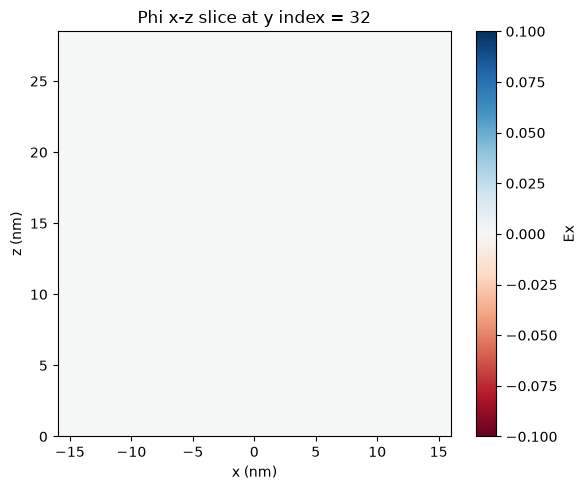

yt : [INFO     ] 2026-07-21 17:29:50,504 Parameters: current_time              = 1.049999999999997e-10


yt : [INFO     ] 2026-07-21 17:29:50,506 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-07-21 17:29:50,507 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-07-21 17:29:50,508 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


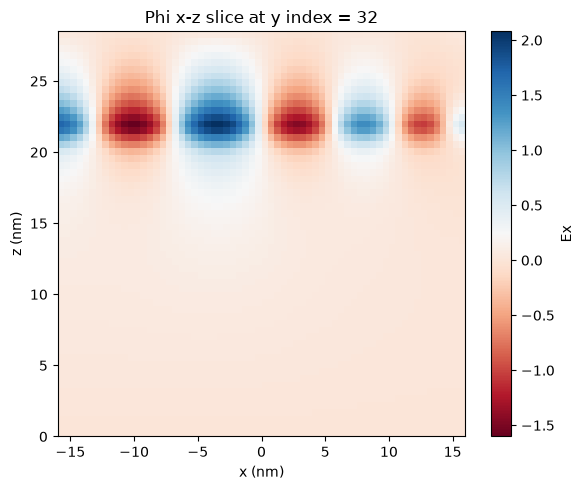

yt : [INFO     ] 2026-07-21 17:29:50,849 Parameters: current_time              = 1.6480000000000185e-10


yt : [INFO     ] 2026-07-21 17:29:50,850 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-07-21 17:29:50,851 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-07-21 17:29:50,853 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


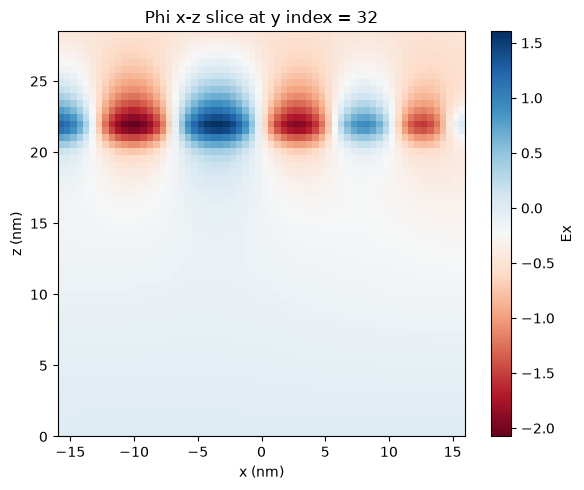

yt : [INFO     ] 2026-07-21 17:29:51,195 Parameters: current_time              = 3.3640000000001013e-10


yt : [INFO     ] 2026-07-21 17:29:51,196 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-07-21 17:29:51,197 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-07-21 17:29:51,199 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


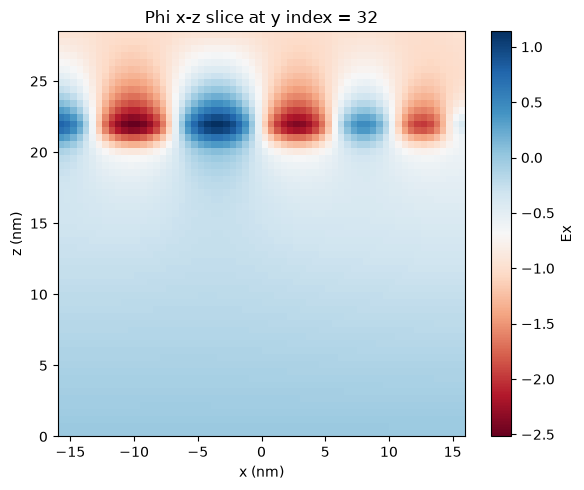

yt : [INFO     ] 2026-07-21 17:29:51,693 Parameters: current_time              = 4.91200000000011e-10


yt : [INFO     ] 2026-07-21 17:29:51,694 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-07-21 17:29:51,696 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-07-21 17:29:51,697 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


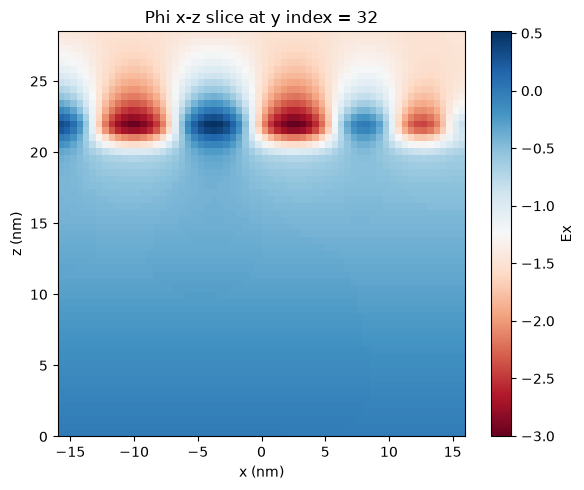

yt : [INFO     ] 2026-07-21 17:29:52,033 Parameters: current_time              = 6.52999999999977e-10


yt : [INFO     ] 2026-07-21 17:29:52,034 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-07-21 17:29:52,035 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-07-21 17:29:52,037 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


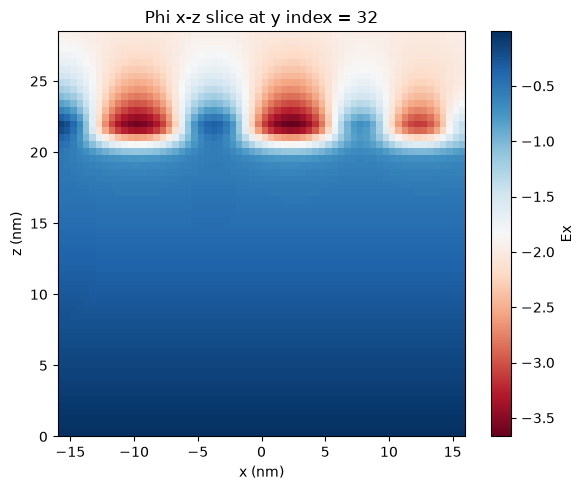

yt : [INFO     ] 2026-07-21 17:29:52,370 Parameters: current_time              = 1.2316000000000105e-09


yt : [INFO     ] 2026-07-21 17:29:52,371 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-07-21 17:29:52,372 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-07-21 17:29:52,373 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


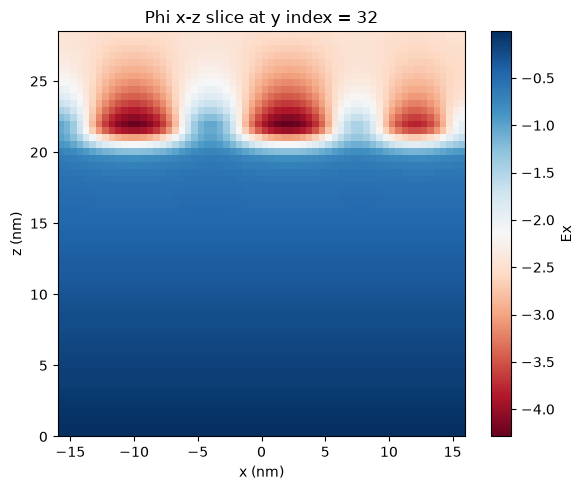

yt : [INFO     ] 2026-07-21 17:29:52,709 Parameters: current_time              = 2.5842000000004254e-09


yt : [INFO     ] 2026-07-21 17:29:52,710 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-07-21 17:29:52,712 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-07-21 17:29:52,713 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


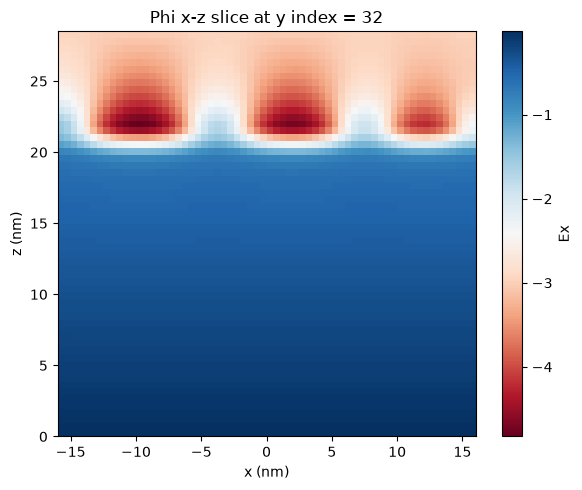

yt : [INFO     ] 2026-07-21 17:29:53,045 Parameters: current_time              = 3.339600000000657e-09


yt : [INFO     ] 2026-07-21 17:29:53,046 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-07-21 17:29:53,047 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-07-21 17:29:53,049 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


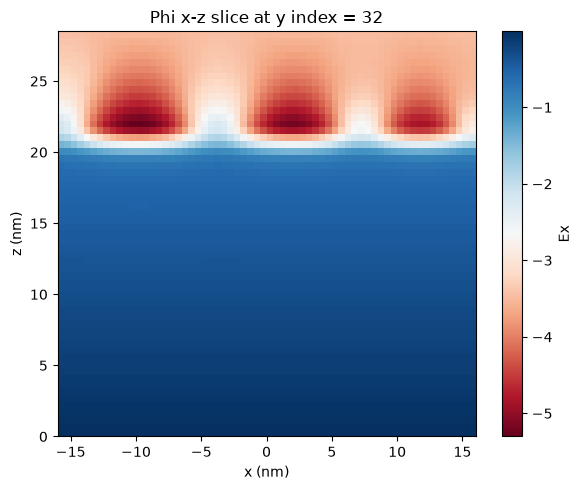

yt : [INFO     ] 2026-07-21 17:29:53,329 Parameters: current_time              = 3.878400000000822e-09


yt : [INFO     ] 2026-07-21 17:29:53,330 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-07-21 17:29:53,331 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-07-21 17:29:53,332 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


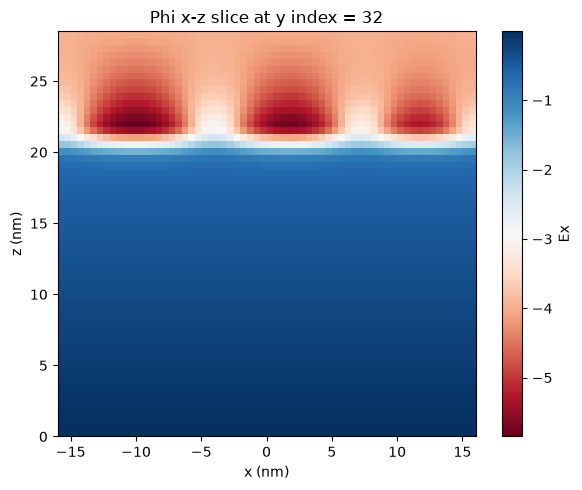

yt : [INFO     ] 2026-07-21 17:29:53,692 Parameters: current_time              = 4.1756000000009136e-09


yt : [INFO     ] 2026-07-21 17:29:53,693 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-07-21 17:29:53,694 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-07-21 17:29:53,695 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


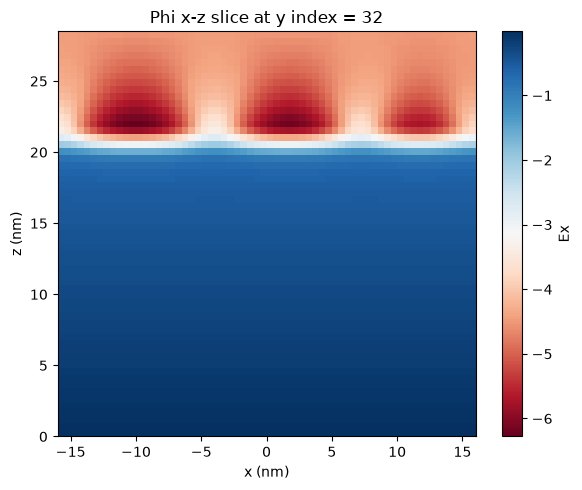

yt : [INFO     ] 2026-07-21 17:29:53,941 Parameters: current_time              = 4.39260000000098e-09


yt : [INFO     ] 2026-07-21 17:29:53,942 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-07-21 17:29:53,943 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-07-21 17:29:53,943 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


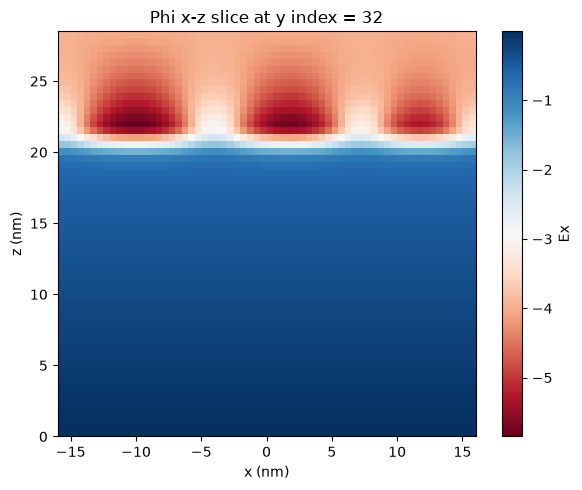

yt : [INFO     ] 2026-07-21 17:29:54,187 Parameters: current_time              = 4.48980000000101e-09


yt : [INFO     ] 2026-07-21 17:29:54,188 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-07-21 17:29:54,189 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-07-21 17:29:54,190 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


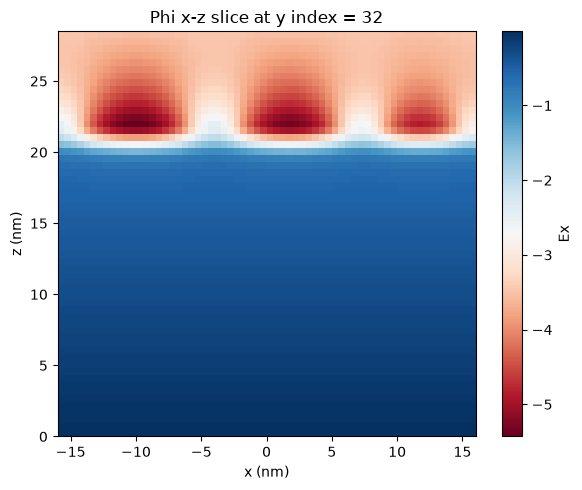

yt : [INFO     ] 2026-07-21 17:29:54,431 Parameters: current_time              = 4.683200000001069e-09


yt : [INFO     ] 2026-07-21 17:29:54,432 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-07-21 17:29:54,433 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-07-21 17:29:54,434 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


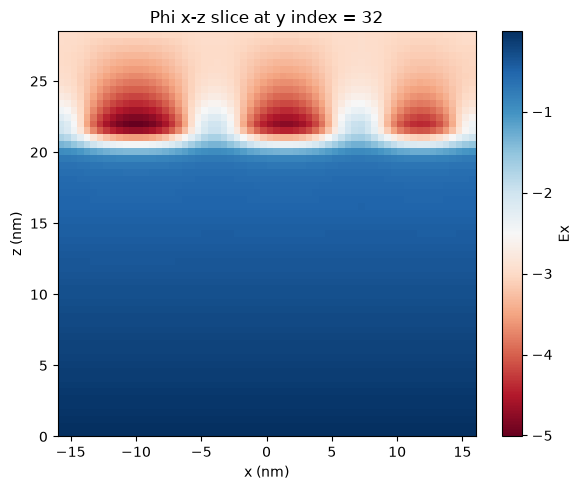

yt : [INFO     ] 2026-07-21 17:29:54,677 Parameters: current_time              = 4.8468000000011194e-09


yt : [INFO     ] 2026-07-21 17:29:54,678 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-07-21 17:29:54,679 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-07-21 17:29:54,680 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


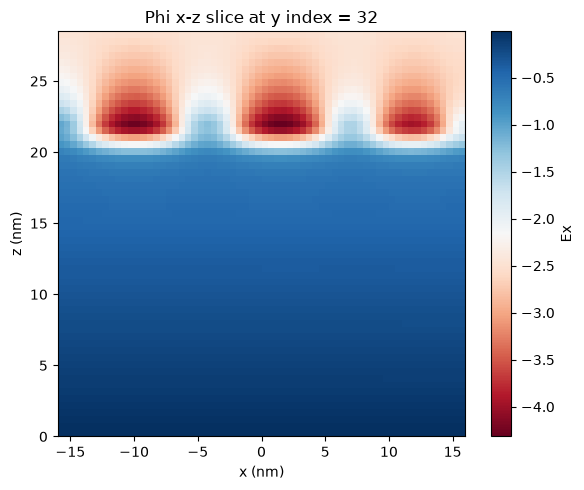

yt : [INFO     ] 2026-07-21 17:29:54,933 Parameters: current_time              = 4.953400000001152e-09


yt : [INFO     ] 2026-07-21 17:29:54,934 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-07-21 17:29:54,935 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-07-21 17:29:54,936 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


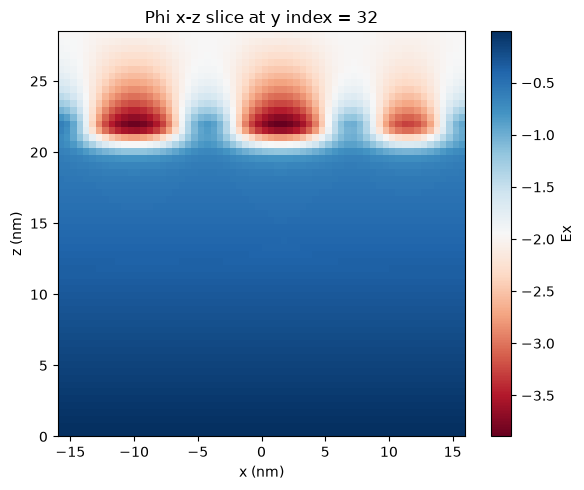

yt : [INFO     ] 2026-07-21 17:29:55,187 Parameters: current_time              = 5.069800000001188e-09


yt : [INFO     ] 2026-07-21 17:29:55,188 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-07-21 17:29:55,189 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-07-21 17:29:55,190 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


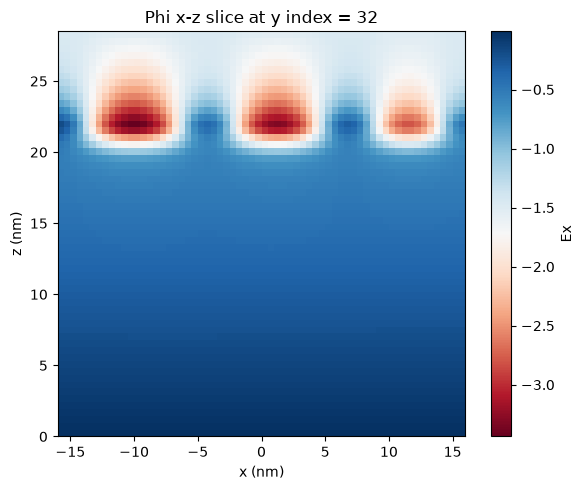

yt : [INFO     ] 2026-07-21 17:29:55,539 Parameters: current_time              = 5.1894000000012245e-09


yt : [INFO     ] 2026-07-21 17:29:55,540 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-07-21 17:29:55,541 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-07-21 17:29:55,542 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


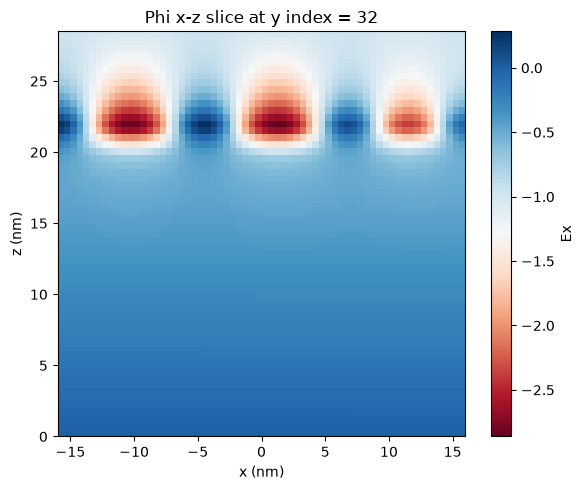

yt : [INFO     ] 2026-07-21 17:29:55,793 Parameters: current_time              = 5.360400000001277e-09


yt : [INFO     ] 2026-07-21 17:29:55,794 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-07-21 17:29:55,795 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-07-21 17:29:55,796 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


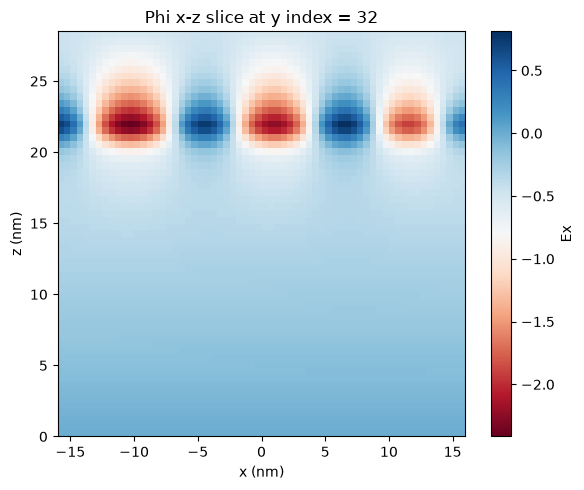

yt : [INFO     ] 2026-07-21 17:29:56,044 Parameters: current_time              = 5.485000000001315e-09


yt : [INFO     ] 2026-07-21 17:29:56,044 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-07-21 17:29:56,045 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-07-21 17:29:56,046 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


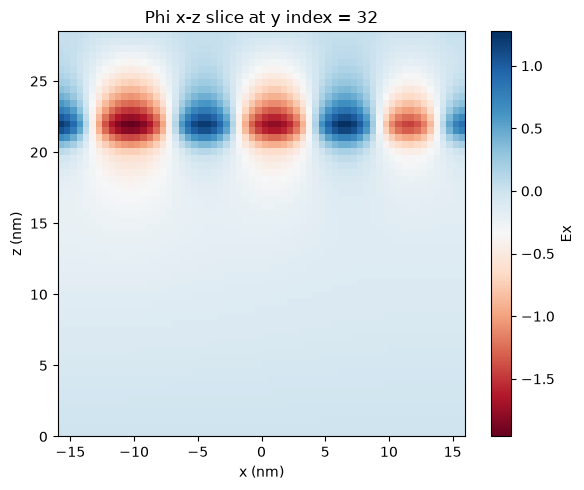

yt : [INFO     ] 2026-07-21 17:29:56,292 Parameters: current_time              = 5.637000000001362e-09


yt : [INFO     ] 2026-07-21 17:29:56,293 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-07-21 17:29:56,294 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-07-21 17:29:56,295 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


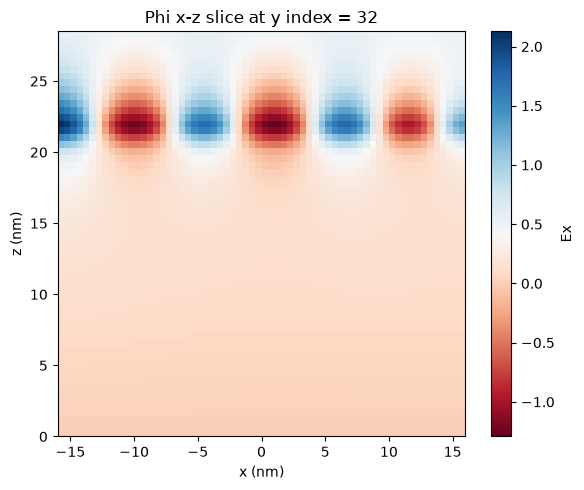

yt : [INFO     ] 2026-07-21 17:29:56,541 Parameters: current_time              = 5.726000000001389e-09


yt : [INFO     ] 2026-07-21 17:29:56,542 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-07-21 17:29:56,543 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-07-21 17:29:56,544 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


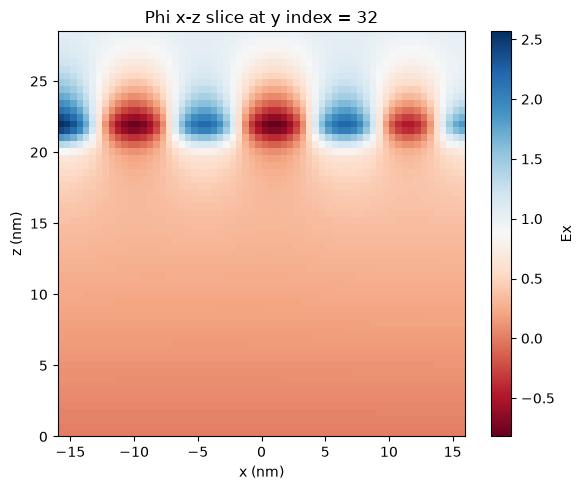

yt : [INFO     ] 2026-07-21 17:29:56,792 Parameters: current_time              = 5.947200000001457e-09


yt : [INFO     ] 2026-07-21 17:29:56,793 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-07-21 17:29:56,794 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-07-21 17:29:56,795 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


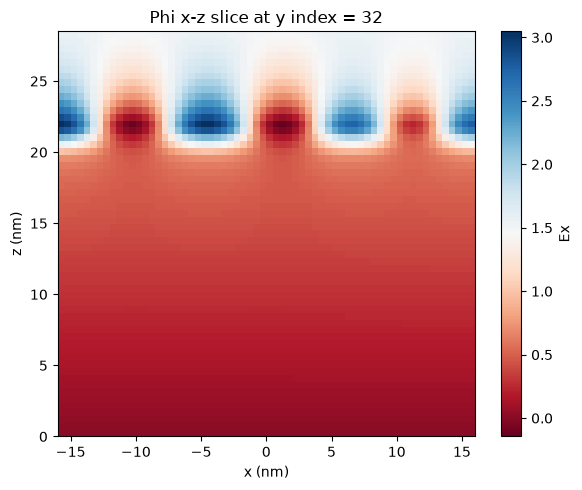

yt : [INFO     ] 2026-07-21 17:29:57,157 Parameters: current_time              = 6.096000000001503e-09


yt : [INFO     ] 2026-07-21 17:29:57,158 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-07-21 17:29:57,159 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-07-21 17:29:57,160 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


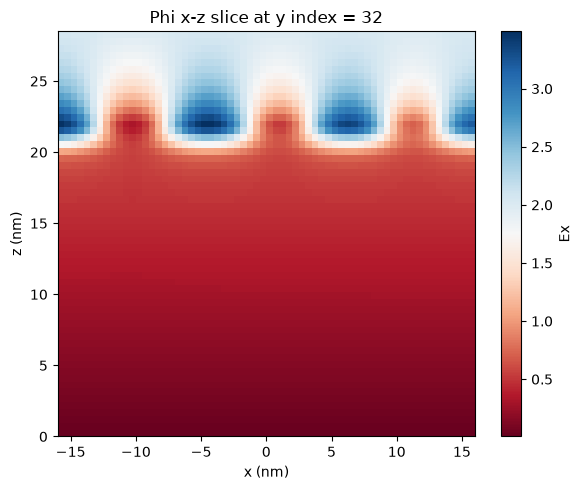

yt : [INFO     ] 2026-07-21 17:29:57,410 Parameters: current_time              = 6.4476000000016105e-09


yt : [INFO     ] 2026-07-21 17:29:57,412 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-07-21 17:29:57,413 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-07-21 17:29:57,413 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


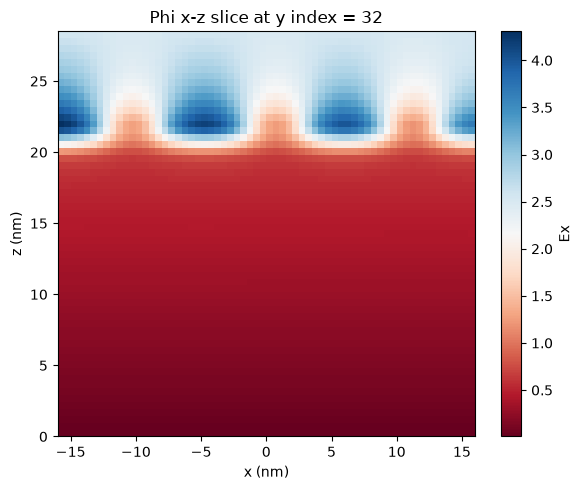

yt : [INFO     ] 2026-07-21 17:29:57,671 Parameters: current_time              = 7.166200000001831e-09


yt : [INFO     ] 2026-07-21 17:29:57,672 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-07-21 17:29:57,673 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-07-21 17:29:57,674 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


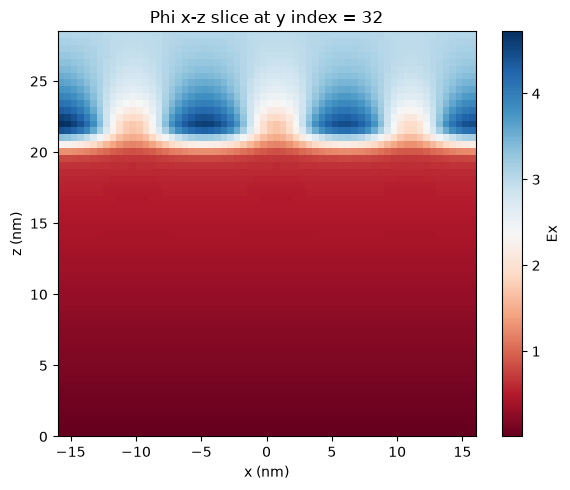

yt : [INFO     ] 2026-07-21 17:29:57,917 Parameters: current_time              = 7.685800000001017e-09


yt : [INFO     ] 2026-07-21 17:29:57,918 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-07-21 17:29:57,919 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-07-21 17:29:57,920 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


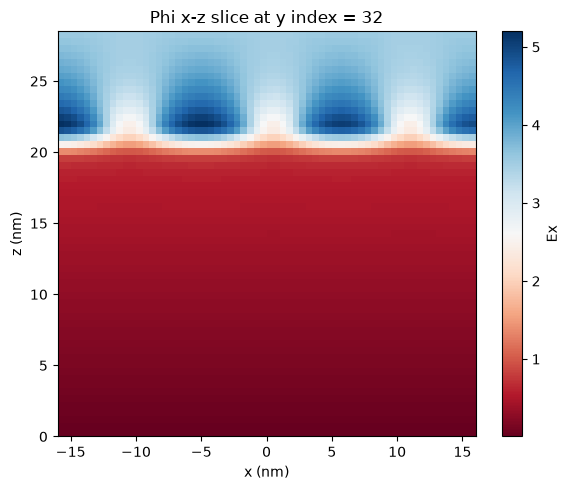

yt : [INFO     ] 2026-07-21 17:29:58,161 Parameters: current_time              = 8.638399999997369e-09


yt : [INFO     ] 2026-07-21 17:29:58,162 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-07-21 17:29:58,163 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-07-21 17:29:58,164 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


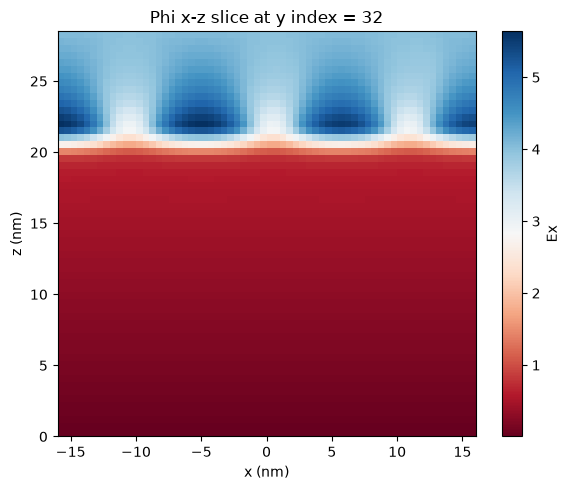

yt : [INFO     ] 2026-07-21 17:29:58,406 Parameters: current_time              = 9.136199999995463e-09


yt : [INFO     ] 2026-07-21 17:29:58,407 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-07-21 17:29:58,408 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-07-21 17:29:58,409 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


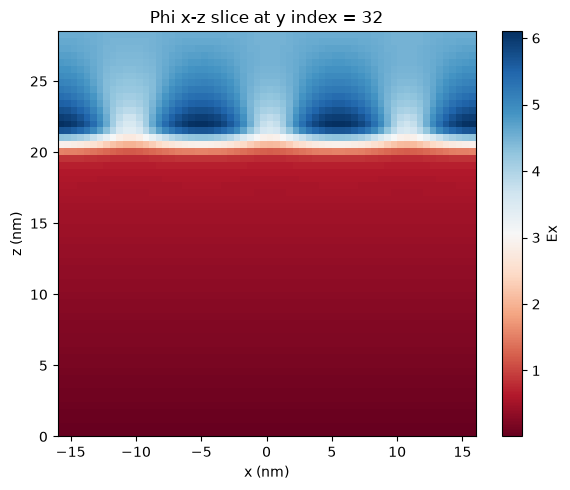

yt : [INFO     ] 2026-07-21 17:29:58,770 Parameters: current_time              = 9.349999999994644e-09


yt : [INFO     ] 2026-07-21 17:29:58,771 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-07-21 17:29:58,772 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-07-21 17:29:58,773 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


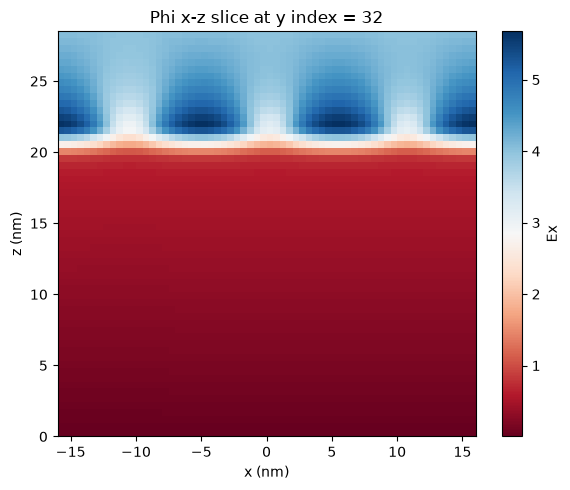

yt : [INFO     ] 2026-07-21 17:29:59,015 Parameters: current_time              = 9.479599999994148e-09


yt : [INFO     ] 2026-07-21 17:29:59,015 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-07-21 17:29:59,016 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-07-21 17:29:59,017 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


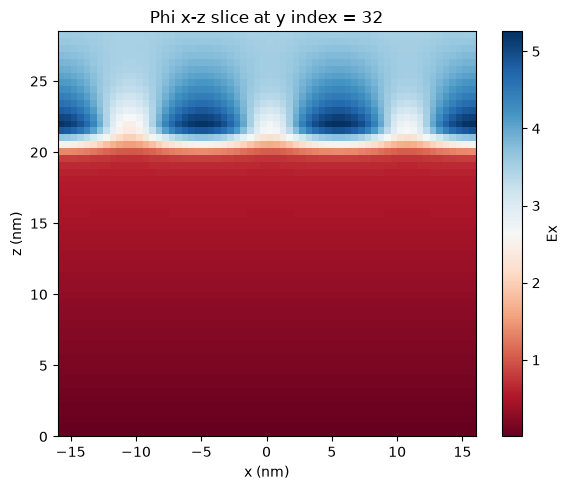

yt : [INFO     ] 2026-07-21 17:29:59,262 Parameters: current_time              = 9.619599999993612e-09


yt : [INFO     ] 2026-07-21 17:29:59,263 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-07-21 17:29:59,264 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-07-21 17:29:59,264 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


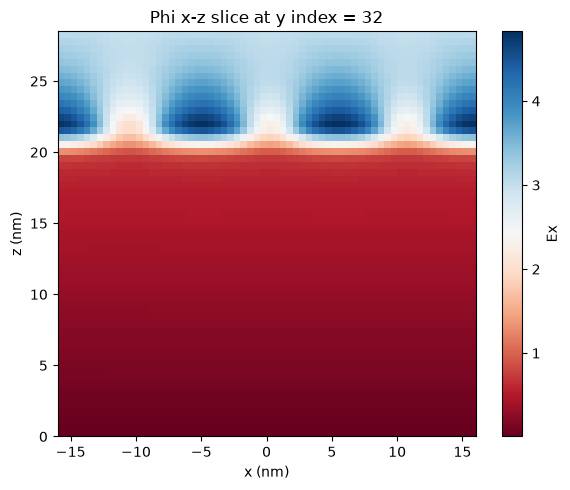

yt : [INFO     ] 2026-07-21 17:29:59,502 Parameters: current_time              = 9.768199999993043e-09


yt : [INFO     ] 2026-07-21 17:29:59,503 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-07-21 17:29:59,504 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-07-21 17:29:59,505 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


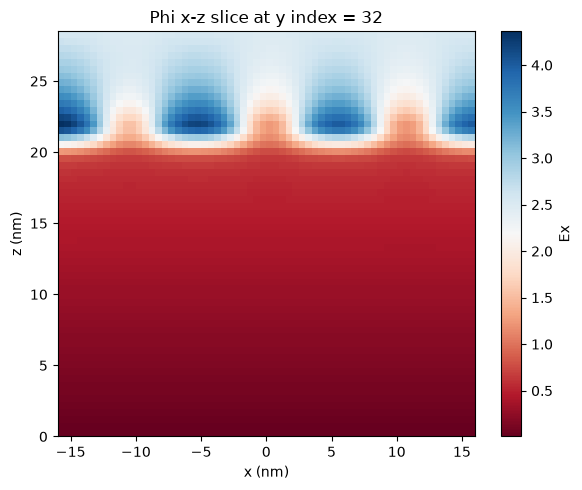

yt : [INFO     ] 2026-07-21 17:29:59,756 Parameters: current_time              = 9.955799999992324e-09


yt : [INFO     ] 2026-07-21 17:29:59,757 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-07-21 17:29:59,758 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-07-21 17:29:59,759 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


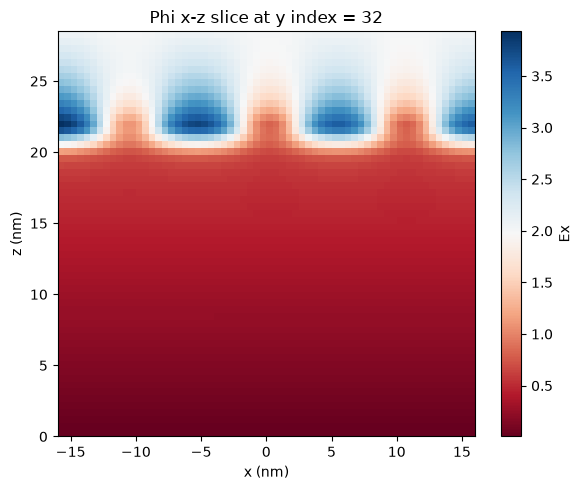

yt : [INFO     ] 2026-07-21 17:30:00,007 Parameters: current_time              = 1.0047999999991971e-08


yt : [INFO     ] 2026-07-21 17:30:00,008 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-07-21 17:30:00,009 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-07-21 17:30:00,009 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


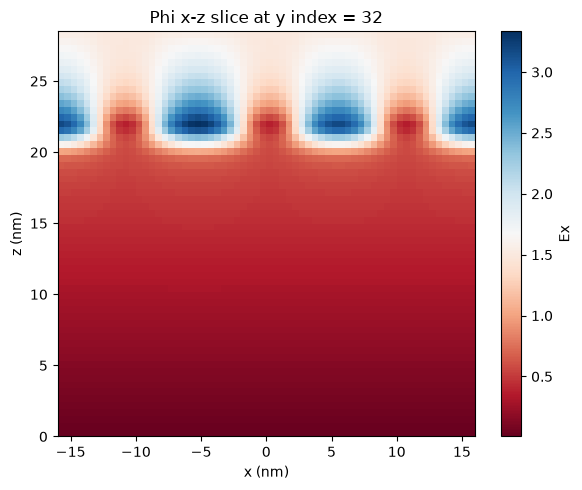

yt : [INFO     ] 2026-07-21 17:30:00,368 Parameters: current_time              = 1.0115399999991713e-08


yt : [INFO     ] 2026-07-21 17:30:00,369 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-07-21 17:30:00,370 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-07-21 17:30:00,370 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


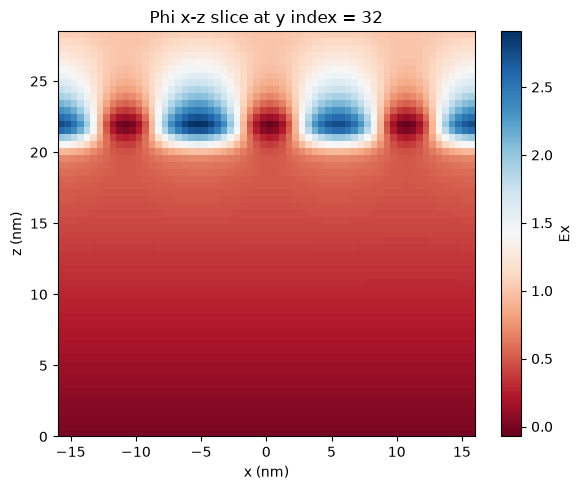

yt : [INFO     ] 2026-07-21 17:30:00,614 Parameters: current_time              = 1.0227199999991285e-08


yt : [INFO     ] 2026-07-21 17:30:00,615 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-07-21 17:30:00,616 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-07-21 17:30:00,617 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


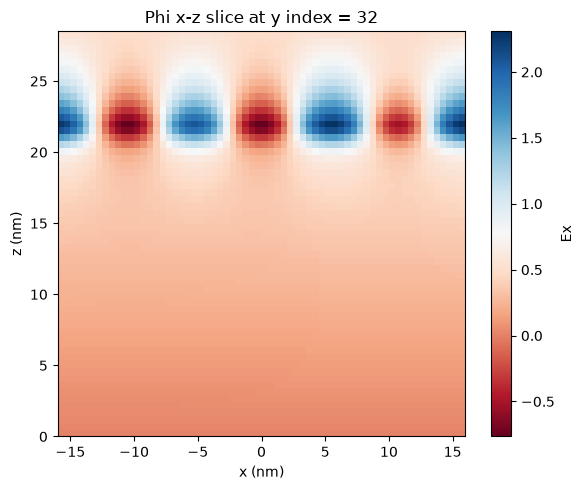

yt : [INFO     ] 2026-07-21 17:30:00,863 Parameters: current_time              = 1.0371799999990732e-08


yt : [INFO     ] 2026-07-21 17:30:00,864 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-07-21 17:30:00,865 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-07-21 17:30:00,866 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


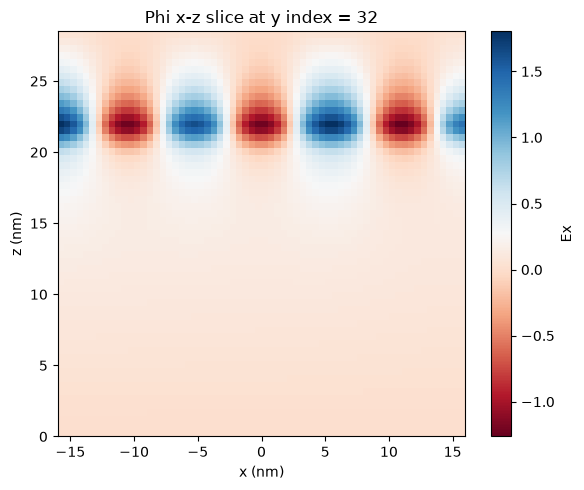

yt : [INFO     ] 2026-07-21 17:30:01,112 Parameters: current_time              = 1.0423599999990533e-08


yt : [INFO     ] 2026-07-21 17:30:01,113 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-07-21 17:30:01,114 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-07-21 17:30:01,115 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


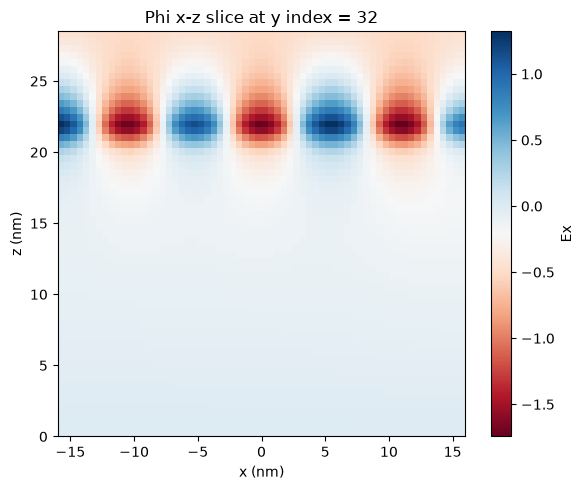

yt : [INFO     ] 2026-07-21 17:30:01,365 Parameters: current_time              = 1.0502399999990231e-08


yt : [INFO     ] 2026-07-21 17:30:01,366 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-07-21 17:30:01,367 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-07-21 17:30:01,368 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


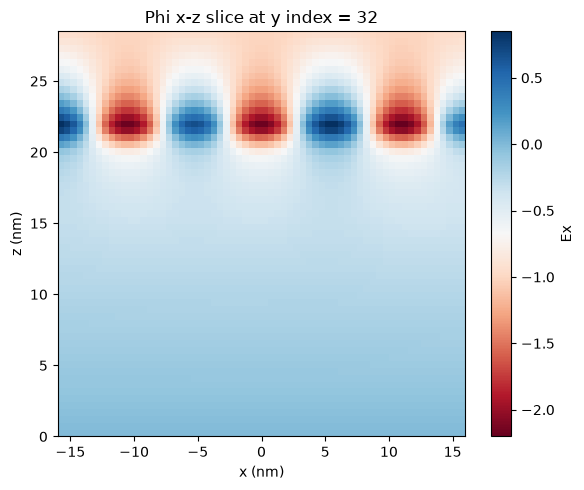

yt : [INFO     ] 2026-07-21 17:30:01,621 Parameters: current_time              = 1.0699399999989477e-08


yt : [INFO     ] 2026-07-21 17:30:01,621 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-07-21 17:30:01,622 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-07-21 17:30:01,623 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


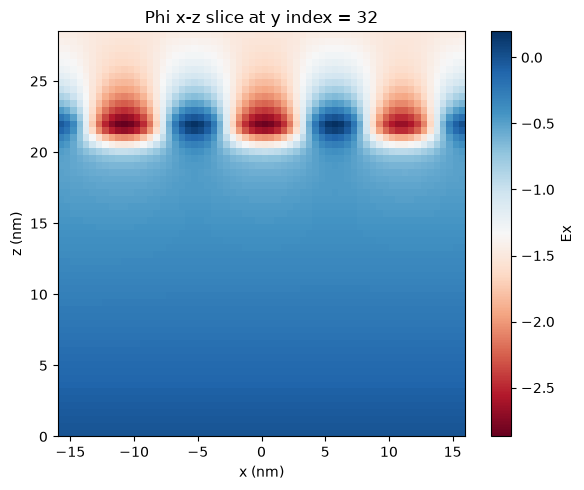

yt : [INFO     ] 2026-07-21 17:30:01,998 Parameters: current_time              = 1.0929999999988594e-08


yt : [INFO     ] 2026-07-21 17:30:01,999 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-07-21 17:30:02,000 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-07-21 17:30:02,001 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


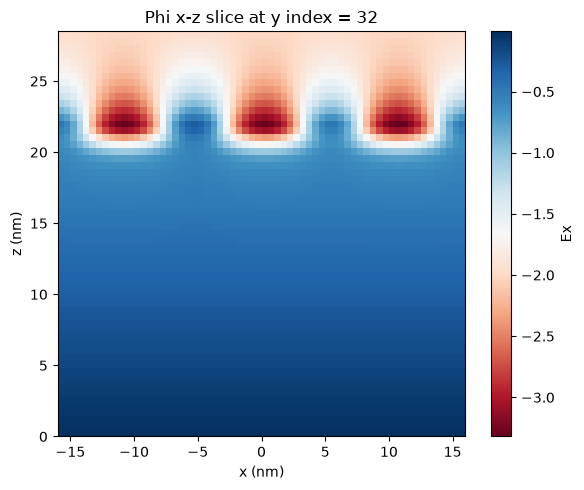

yt : [INFO     ] 2026-07-21 17:30:02,248 Parameters: current_time              = 1.1443599999986627e-08


yt : [INFO     ] 2026-07-21 17:30:02,249 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-07-21 17:30:02,250 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-07-21 17:30:02,251 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


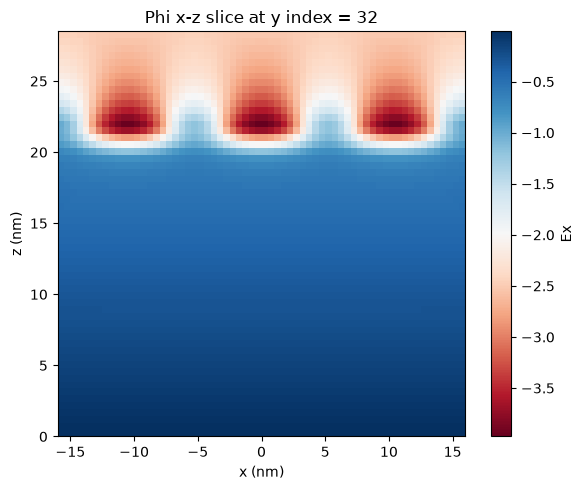

yt : [INFO     ] 2026-07-21 17:30:02,502 Parameters: current_time              = 1.1751599999985448e-08


yt : [INFO     ] 2026-07-21 17:30:02,502 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-07-21 17:30:02,503 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-07-21 17:30:02,504 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


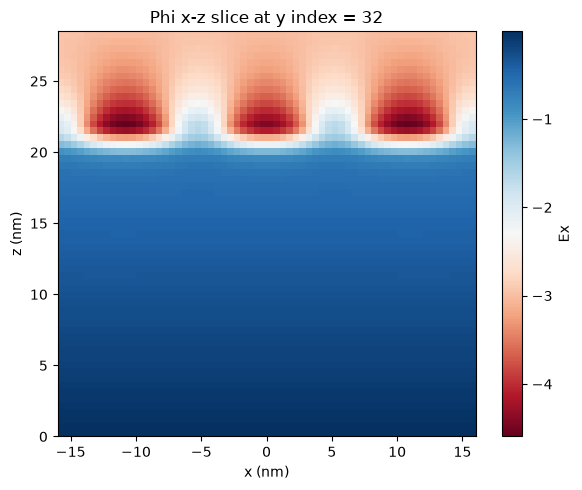

yt : [INFO     ] 2026-07-21 17:30:02,745 Parameters: current_time              = 1.2053399999984292e-08


yt : [INFO     ] 2026-07-21 17:30:02,746 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-07-21 17:30:02,747 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-07-21 17:30:02,748 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


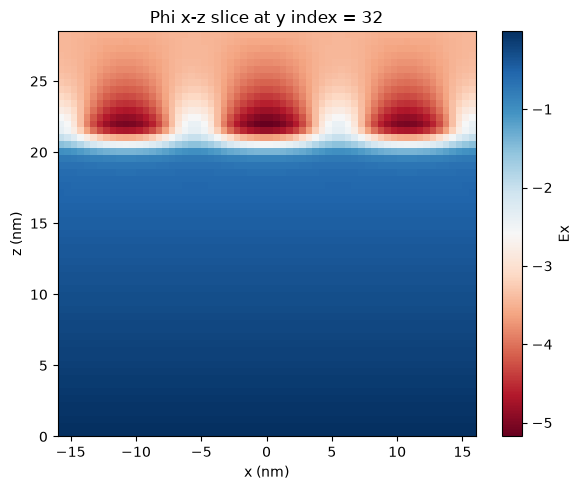

yt : [INFO     ] 2026-07-21 17:30:02,992 Parameters: current_time              = 1.2456799999982748e-08


yt : [INFO     ] 2026-07-21 17:30:02,993 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-07-21 17:30:02,994 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-07-21 17:30:02,995 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


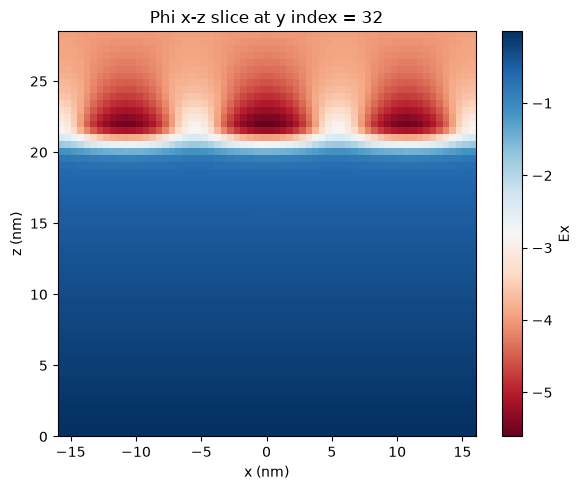

yt : [INFO     ] 2026-07-21 17:30:03,237 Parameters: current_time              = 1.3145199999980112e-08


yt : [INFO     ] 2026-07-21 17:30:03,238 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-07-21 17:30:03,239 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-07-21 17:30:03,240 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


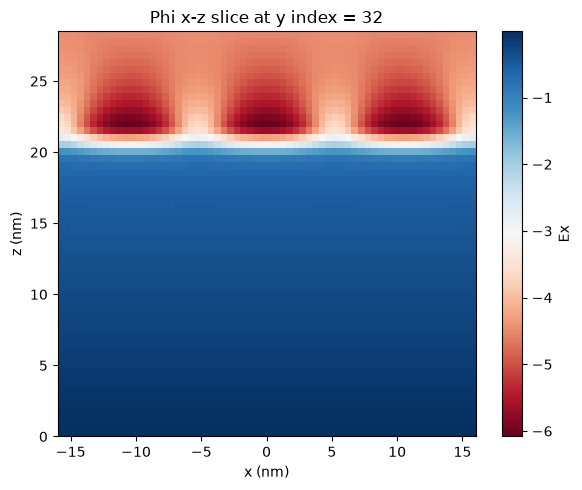

In [13]:
import yt
import numpy as np
import matplotlib.pyplot as plt
for i in range(len(plot_names)):
    plotfile = PLOT_DIR/plot_names[i] 
    field = ("boxlib", "Phi")

    ds = yt.load(plotfile)

    #g = ds.index.grids[0] # 先看 grid 0，多個 grid 的話要自己想辦法合併資料
    Phi_array = read_full_field_from_grids(ds, field) # 讀取整個 domain 的 Phi 資料，會自動合併多個 grid

    print("Phi_array shape =", Phi_array.shape)

    Nx, Ny, Nz = Phi_array.shape #用index存資料

    lo = ds.domain_left_edge.to_value()
    hi = ds.domain_right_edge.to_value()
    dims = np.array([Nx, Ny, Nz])

    dx = (hi - lo) / dims

    x_nm = (lo[0] + (np.arange(Nx) + 0.5) * dx[0]) * 1e9 #index對應空間位置
    z_nm = (lo[2] + (np.arange(Nz) + 0.5) * dx[2]) * 1e9

    y0 = Ny // 2
    slice2d = Phi_array[:, y0, :]

    plt.figure(figsize=(6, 5))
    im = plt.pcolormesh(
        x_nm,
        z_nm,
        slice2d.T,
        shading="auto",
        cmap="RdBu"
    )

    plt.colorbar(im, label="Ex")
    plt.xlabel("x (nm)")
    plt.ylabel("z (nm)")
    plt.title(f"Phi x-z slice at y index = {y0}")
    plt.tight_layout()
    plt.show()

yt : [INFO     ] 2026-07-21 17:30:03,601 Parameters: current_time              = 1.6480000000000185e-10


yt : [INFO     ] 2026-07-21 17:30:03,603 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-07-21 17:30:03,605 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-07-21 17:30:03,606 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


E_array shape = (64, 64, 59)


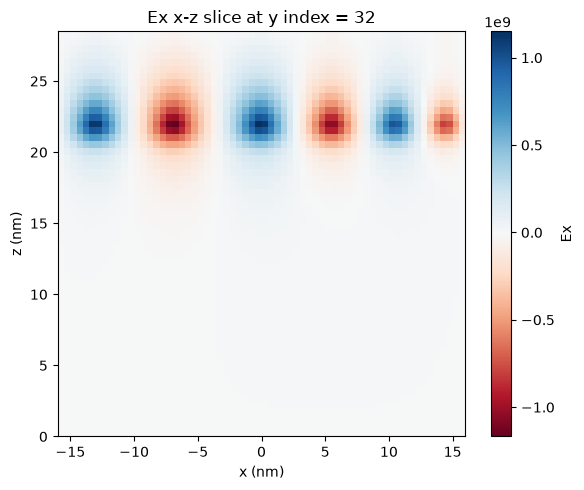

In [14]:
import yt
import numpy as np
import matplotlib.pyplot as plt

#PLOT_DIR = Path("/home/kaiwi/FAM/FerroX/Exec/MFIS_t_8_plt")  # 改成你 plotfile 所在的資料夾
plotfile = PLOT_DIR/plot_names[2] 
field = ("boxlib", "Ex")

ds = yt.load(plotfile)

#g = ds.index.grids[0] # 先看 grid 0，多個 grid 的話要自己想辦法合併資料
E_array = read_full_field_from_grids(ds, field) # 讀取整個 domain 的 Ex 資料，會自動合併多個 grid

print("E_array shape =", E_array.shape)

Nx, Ny, Nz = E_array.shape #用index存資料

lo = ds.domain_left_edge.to_value()
hi = ds.domain_right_edge.to_value()
dims = np.array([Nx, Ny, Nz])

dx = (hi - lo) / dims

x_nm = (lo[0] + (np.arange(Nx) + 0.5) * dx[0]) * 1e9 #index對應空間位置
z_nm = (lo[2] + (np.arange(Nz) + 0.5) * dx[2]) * 1e9

y0 = Ny // 2
slice2d = E_array[:, y0, :]

plt.figure(figsize=(6, 5))
im = plt.pcolormesh(
    x_nm,
    z_nm,
    slice2d.T,
    shading="auto",
    cmap="RdBu"
)

plt.colorbar(im, label="Ex")
plt.xlabel("x (nm)")
plt.ylabel("z (nm)")
plt.title(f"Ex x-z slice at y index = {y0}")
plt.tight_layout()
plt.show()

## 2D Pz slice plot(all voltage in same graph)

yt : [INFO     ] 2026-07-21 17:30:03,884 Parameters: current_time              = 4.1756000000009136e-09


yt : [INFO     ] 2026-07-21 17:30:03,884 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-07-21 17:30:03,885 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


Plotfiles to draw:
  plt00020878
  plt00021963
  plt00022449
  plt00023416
  plt00024234
  plt00024767
  plt00025349
  plt00025947
  plt00026802
  plt00027425
  plt00028185
  plt00028630
  plt00029736
  plt00030480
  plt00032238
  plt00035831
  plt00038429
  plt00043192
  plt00045681
  plt00046750
  plt00047398
  plt00048098
  plt00048841
  plt00049779
  plt00050240
  plt00050577
  plt00051136
  plt00051859
  plt00052118
  plt00052512
  plt00053497
  plt00054650
  plt00057218
  plt00058758
  plt00060267
  plt00062284
  plt00065726
37 number of plotfiles will be drawn after filtering.


yt : [INFO     ] 2026-07-21 17:30:03,886 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


...

yt : [INFO     ] 2026-07-21 17:30:08,791 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-07-21 17:30:08,792 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-07-21 17:30:08,793 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Drawing 37 plots after filtering.


Saved figure: ./figs/Pz_FE_layer_stack.png


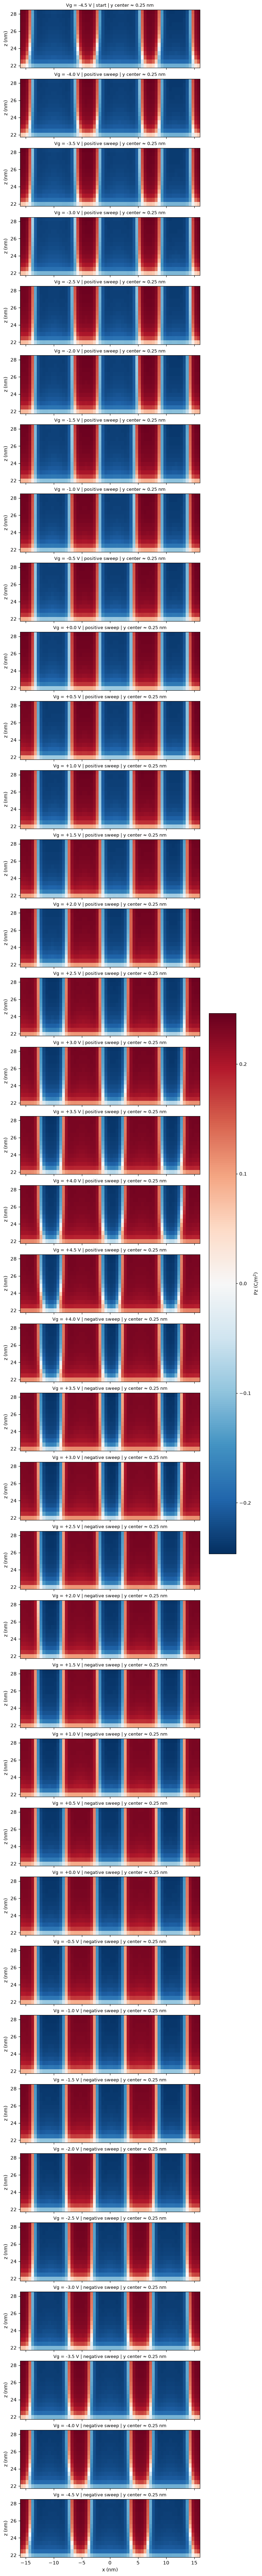

In [15]:
from pathlib import Path
import re

import yt
import numpy as np
import matplotlib.pyplot as plt


# ==========================
# User settings
# ==========================

#PLOT_DIR = Path("/home/kaiwi/FAM/FerroX/Exec")          # plotfile 所在資料夾
P_FIELD = ("boxlib", "Pz")
PHI_FIELD = ("boxlib", "Phi")

# ==========================
# Selection list (NEW)
# ==========================
# format: (voltage, direction)
# voltage 用 None 表示 wildcard
# direction 用 None 表示 wildcard
'''
SELECT_LIST = [
    
    (-0.5, "positive sweep"), 
    (-0.5, "negative sweep"),
   
]
'''
SELECT_LIST = None  # 不過濾，全部畫出來
USE_FE_X_RANGE = False

# y slice: None 表示取 y 方向正中間
Y_INDEX = None

# 若 plot_names 已經是你前面整理好的 steady-state plot list，就直接用
# plot_names = [...]
# 若沒有，就自動抓目前資料夾內所有 plt########
AUTO_FIND_PLOTS = False

# 跳過 initial plt00000000
SKIP_INITIAL = True

# 色階是否對稱於 0，畫 Pz 通常建議 True
SYMMETRIC_COLOR_SCALE = False

# 輸出圖片名稱
SAVE_FIG = True
OUT_FIG = "./figs/Pz_FE_layer_stack.png"


# ==========================
# Helper functions
# ==========================


def to_numpy(field_data):
    try:
        return field_data.to_ndarray()
    except AttributeError:
        return field_data.v


def read_one_plot(plotfile, y_index=None):
    ds = yt.load(str(plotfile))
    #g = ds.index.grids[0]

    P = read_full_field_from_grids(ds, P_FIELD) # 讀取整個 domain 的 Pz 資料，會自動合併多個 grid
    P*=-1
    if PHI_FIELD in ds.field_list:
        Phi = read_full_field_from_grids(ds, PHI_FIELD) # 讀取整個 domain 的 Phi 資料，會自動合併多個 grid
    else:
        Phi = None

    Nx, Ny, Nz = P.shape

    lo = ds.domain_left_edge.to_value()
    hi = ds.domain_right_edge.to_value()
    dx = (hi - lo) / np.array([Nx, Ny, Nz])

    x_nm = (lo[0] + (np.arange(Nx) + 0.5) * dx[0]) * 1e9
    y_nm = (lo[1] + (np.arange(Ny) + 0.5) * dx[1]) * 1e9
    z_nm = (lo[2] + (np.arange(Nz) + 0.5) * dx[2]) * 1e9

    if y_index is None:
        y_index = Ny // 2

    # FE z range mask
    z_sel = (z_nm >= FE_Z_LO_NM) & (z_nm <= FE_Z_HI_NM)

    if USE_FE_X_RANGE:
        x_sel = (x_nm >= FE_X_LO_NM) & (x_nm <= FE_X_HI_NM)
    else:
        x_sel = np.ones_like(x_nm, dtype=bool)

    # P slice: shape after selection = (Nx_sel, Nz_sel)
    P_slice = P[np.ix_(x_sel, [y_index], z_sel)][:, 0, :]

    x_plot = x_nm[x_sel]
    z_plot = z_nm[z_sel]

    # 用最上層 cell 的 Phi 平均值當 top potential
    # 注意：這是 top cell center，不是真正 ghost boundary
    if Phi is not None:
        top_phi = Phi[:, :, -1]
        Vtop_mean = float(np.mean(top_phi))
        Vtop_min = float(np.min(top_phi))
        Vtop_max = float(np.max(top_phi))
    else:
        Vtop_mean = np.nan
        Vtop_min = np.nan
        Vtop_max = np.nan

    info = {
        "ds": ds,
        "P_slice": P_slice,
        "x_nm": x_plot,
        "z_nm": z_plot,
        "y_index": y_index,
        "y_nm": float(y_nm[y_index]),
        "Vtop_mean": Vtop_mean,
        "Vtop_min": Vtop_min,
        "Vtop_max": Vtop_max,
        "shape": P.shape,
    }

    return info



def match(rec, direction):# FILTER BY SELECT_LIST
    if not SELECT_LIST:
        return True
    V = rec["Vtop_mean"]

    for v_target, d_target in SELECT_LIST:

        ok_v = (v_target is None) or (
            np.isfinite(V) and np.isclose(V, v_target, atol=1e-1)
        )

        ok_d = (d_target is None) or (direction == d_target)

        if ok_v and ok_d:
            return True

    return False

# ==========================
# Main
# ==========================

if AUTO_FIND_PLOTS:
    plot_names_use = find_plot_names(PLOT_DIR)
else:
    plot_names_use = list(plot_names)

# sort by step if names are plt########
plot_names_use = sorted(plot_names_use, key=lambda n: get_step_from_name(n) if get_step_from_name(n) is not None else 10**99)

if SKIP_INITIAL:
    plot_names_use = [
        n for n in plot_names_use
        if get_step_from_name(n) != 0
    ]

#忽略第一段
plot_names_use = plot_names_use[9:]
    
print("Plotfiles to draw:")
for n in plot_names_use:
    print(" ", n)
print(len(plot_names_use), "number of plotfiles will be drawn after filtering.")

records = []
all_values = []

for name in plot_names_use:
    plotfile = PLOT_DIR / name
    info = read_one_plot(plotfile, y_index=Y_INDEX)

    step = get_step_from_name(name)

    records.append({
        "name": name,
        "step": step,
        **info,
    })

    all_values.append(info["P_slice"])

# shared color scale
all_concat = np.concatenate([v.ravel() for v in all_values])
if SYMMETRIC_COLOR_SCALE:
    vmax = np.nanmax(np.abs(all_concat))
    vmin = -vmax
else:
    vmin = np.nanmin(all_concat)
    vmax = np.nanmax(all_concat)

# determine sweep direction from Vtop sequence
Vseq = np.array([r["Vtop_mean"] for r in records], dtype=float)

directions = []
for idx, V in enumerate(Vseq):
    if idx == 0 or not np.isfinite(Vseq[idx-1]) or not np.isfinite(V):
        directions.append("start")
    else:
        dV = V - Vseq[idx-1]
        if dV > 1e-8:
            directions.append("positive sweep")
        elif dV < -1e-8:
            directions.append("negative sweep")
        else:
            directions.append("same V")

filtered_records = []
filtered_directions = []

for rec, d in zip(records, directions):
    if match(rec, d):
        filtered_records.append(rec)
        filtered_directions.append(d)

records = filtered_records
directions = filtered_directions

# figure size
n = len(records)
print(f"Drawing {n} plots after filtering.")
fig_height = max(2.0 * n, 4.0)
fig, axes = plt.subplots(
    nrows=n,
    ncols=1,
    figsize=(7.5, fig_height),
    sharex=True,
    constrained_layout=True
)


if n == 1:
    axes = [axes]

last_im = None

for ax, rec, sweep_dir in zip(axes, records, directions):
    P_slice = rec["P_slice"]
    x_nm = rec["x_nm"]
    z_nm = rec["z_nm"]

    last_im = ax.pcolormesh(
        x_nm,
        z_nm,
        P_slice.T,
        shading="auto",
        cmap="RdBu_r",
        vmin=vmin,
        vmax=vmax
    )

    Vmean = rec["Vtop_mean"]
    Vmin = rec["Vtop_min"]
    Vmax = rec["Vtop_max"]

    if np.isfinite(Vmean):
        v_label = f"Vg = {Vmean:+.1f} V"
        # 若你想檢查 top x/y variation，也可以顯示 min/max
        # v_label += f" [{Vmin:+.3f}, {Vmax:+.3f}]"
    else:
        v_label = "Vtop unavailable"

    step_label = f"step={rec['step']}" if rec["step"] is not None else rec["name"]

    ax.set_ylabel("z (nm)")

    ax.set_title(
        f"{v_label} | {sweep_dir} | "
        f"y center ≈ {rec['y_nm']:.2f} nm",
        fontsize=9
    )

axes[-1].set_xlabel("x (nm)")
axes[-1].tick_params(axis='x', labelbottom=True)
'''
for ax in axes:
    ax.set_xlabel("x (nm)")
    ax.tick_params(axis='x', labelbottom=True)
'''
cbar = fig.colorbar(last_im, ax=axes, shrink=0.8)
cbar.set_label(r"Pz (C/m$^2$)")

if SAVE_FIG:
    fig.savefig(OUT_FIG, dpi=200)
    print(f"Saved figure: {OUT_FIG}")

plt.show()

## PV

### User Settings

In [16]:
from pathlib import Path
import re

import yt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ==========================
# User settings
# ==========================

#PLOT_DIR = Path("/home/kaiwi/FAM/FerroX/Exec/MFIS_t_8_1_plt")

P_FIELD = ("boxlib", "Pz")
PHI_FIELD = ("boxlib", "Phi")


# 如果 FE 是全幅 MFIS，通常不用限制 x/y
USE_FE_X_RANGE = False


USE_FE_Y_RANGE = False
# 若你已經有 steady-state plot_names，就用 AUTO_FIND_PLOTS=False
# plot_names = [...]
AUTO_FIND_PLOTS = True

# 如果沒有 plot_names，可以自動找所有 plt########
# 但建議最好只用 steady-state plotfiles
SKIP_INITIAL = True

OUT_CSV = "./figs/MFIS_PV_curve.csv"
OUT_FIG = "./figs/MFIS_PV_curve.png"


### Utils

In [17]:
# ==========================
# Helper functions
# ==========================

def get_step_from_name(name):
    m = re.fullmatch(r"plt(\d+)", str(name))
    return int(m.group(1)) if m else None


def find_plot_names(plot_dir):
    names = []
    for p in plot_dir.iterdir():
        if p.is_dir() and re.fullmatch(r"plt\d+", p.name):
            names.append(p.name)
    names.sort(key=lambda n: get_step_from_name(n))
    return names


def to_numpy(field_data):
    try:
        return field_data.to_ndarray()
    except AttributeError:
        return field_data.v

def read_full_field_from_grids(ds, field):
    """
    Read a cell-centered AMReX field from all yt grids
    and stitch them into one full-domain numpy array.

    Return:
        full: numpy array with shape ds.domain_dimensions
    """
    dims = np.array(ds.domain_dimensions, dtype=int)
    full = np.empty(tuple(dims), dtype=float)

    domain_lo = ds.domain_left_edge.to_value()
    domain_hi = ds.domain_right_edge.to_value()
    dx = (domain_hi - domain_lo) / dims

    for grid in ds.index.grids:
        arr = to_numpy(grid[field])

        left = grid.LeftEdge.to_value()

        # grid start index in global domain
        start = np.rint((left - domain_lo) / dx).astype(int)

        nx, ny, nz = arr.shape
        i0, j0, k0 = start
        i1, j1, k1 = i0 + nx, j0 + ny, k0 + nz

        full[i0:i1, j0:j1, k0:k1] = arr

    return full

def read_pv_from_plot(plotfile):
    ds = yt.load(str(plotfile))
    Pz = read_full_field_from_grids(ds, P_FIELD)
    Phi = read_full_field_from_grids(ds, PHI_FIELD)

    Nx, Ny, Nz = Pz.shape
    print(f"Read Pz with shape {Pz.shape} from {plotfile}")

    lo = ds.domain_left_edge.to_value()
    hi = ds.domain_right_edge.to_value()
    print(f"Domain: x [{lo[0]:.3e}, {hi[0]:.3e}] m, "
          f"y [{lo[1]:.3e}, {hi[1]:.3e}] m, "
          f"z [{lo[2]:.3e}, {hi[2]:.3e}] m")
    dx = (hi - lo) / np.array([Nx, Ny, Nz])

    x_nm = (lo[0] + (np.arange(Nx) + 0.5) * dx[0]) * 1e9
    y_nm = (lo[1] + (np.arange(Ny) + 0.5) * dx[1]) * 1e9
    z_nm = (lo[2] + (np.arange(Nz) + 0.5) * dx[2]) * 1e9

    z_sel = (z_nm >= FE_Z_LO_NM) & (z_nm <= FE_Z_HI_NM)

    if USE_FE_X_RANGE:
        x_sel = (x_nm >= FE_X_LO_NM) & (x_nm <= FE_X_HI_NM)
    else:
        x_sel = np.ones_like(x_nm, dtype=bool)

    if USE_FE_Y_RANGE:
        y_sel = (y_nm >= FE_Y_LO_NM) & (y_nm <= FE_Y_HI_NM)
    else:
        y_sel = np.ones_like(y_nm, dtype=bool)

    Pz_FE = Pz[np.ix_(x_sel, y_sel, z_sel)]

    P_mean = float(np.mean(Pz_FE))
    P_min = float(np.min(Pz_FE))
    P_max = float(np.max(Pz_FE))
    P_std = float(np.std(Pz_FE))

    # 用最上層 cell 的 Phi 平均值估 top electrode potential
    # 注意：這是 top cell center，不是真正 ghost boundary
    top_phi = Phi[:, :, -1]
    Vg_mean = float(np.mean(top_phi))
    Vg_min = float(np.min(top_phi))
    Vg_max = float(np.max(top_phi))
    Vg_std = float(np.std(top_phi))

    return {
        "P_mean": P_mean,
        "P_min": P_min,
        "P_max": P_max,
        "P_std": P_std,
        "Vg_mean": Vg_mean,
        "Vg_min": Vg_min,
        "Vg_max": Vg_max,
        "Vg_std": Vg_std,
        "Nx": Nx,
        "Ny": Ny,
        "Nz": Nz,
        "num_FE_cells": int(Pz_FE.size),
    }



### Data Preparation

In [18]:



# ==========================
# Main
# ==========================

if AUTO_FIND_PLOTS:
    print(f"Finding plotfiles in {PLOT_DIR}...")
    plot_names_use = find_plot_names(PLOT_DIR)
else:
    plot_names_use = list(plot_names)

plot_names_use = sorted(
    plot_names_use,
    key=lambda n: get_step_from_name(n) if get_step_from_name(n) is not None else 10**99
)

if SKIP_INITIAL:
    plot_names_use = [
        n for n in plot_names_use
        if get_step_from_name(n) != 0
    ]
plot_names_use = plot_names_use[9:]  # skip first 9 plotfiles
rows = []

print(plot_names_use)

for name in plot_names_use:
    plotfile = PLOT_DIR / name
    step = get_step_from_name(name)

    info = read_pv_from_plot(plotfile)

    rows.append({
        "plotfile": name,
        "step": step,
        **info,
    })

    print(
        f"{name} | step={step} | "
        f"Vg={info['Vg_mean']:+.4f} V | "
        f"<Pz>_FE={info['P_mean']:+.6e}"
    )

df = pd.DataFrame(rows)
df.to_csv(OUT_CSV, index=False)
print(f"Saved CSV: {OUT_CSV}")


# ==========================
# Determine sweep direction
# ==========================

V = df["Vg_mean"].to_numpy()
P = df["P_mean"].to_numpy()


direction = np.zeros_like(V)

for i in range(1, len(V)):
    dV = V[i] - V[i - 1]
    if dV > 1e-8:
        direction[i] = 1   # positive sweep
    elif dV < -1e-8:
        direction[i] = -1  # negative sweep
    else:
        direction[i] = direction[i - 1]

#np.append(direction, direction[-1])  # 複製第一筆到最後

df["sweep_direction"] = direction
df.to_csv(OUT_CSV, index=False)




yt : [INFO     ] 2026-07-21 17:30:16,287 Parameters: current_time              = 4.1756000000009136e-09


yt : [INFO     ] 2026-07-21 17:30:16,288 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-07-21 17:30:16,289 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-07-21 17:30:16,290 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


yt : [INFO     ] 2026-07-21 17:30:16,410 Parameters: current_time              = 4.39260000000098e-09


...

yt : [INFO     ] 2026-07-21 17:30:20,734 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-07-21 17:30:20,735 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-07-21 17:30:20,736 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Read Pz with shape (64, 64, 59) from plts/plt00060267
Domain: x [-1.600e-08, 1.600e-08] m, y [-1.600e-08, 1.600e-08] m, z [0.000e+00, 2.850e-08] m
plt00060267 | step=60267 | Vg=-3.5009 V | <Pz>_FE=+5.969370e-02
Read Pz with shape (64, 64, 59) from plts/plt00062284
Domain: x [-1.600e-08, 1.600e-08] m, y [-1.600e-08, 1.600e-08] m, z [0.000e+00, 2.850e-08] m
plt00062284 | step=62284 | Vg=-3.9978 V | <Pz>_FE=+6.708692e-02


Read Pz with shape (64, 64, 59) from plts/plt00065726
Domain: x [-1.600e-08, 1.600e-08] m, y [-1.600e-08, 1.600e-08] m, z [0.000e+00, 2.850e-08] m
plt00065726 | step=65726 | Vg=-4.5030 V | <Pz>_FE=+7.917636e-02
Saved CSV: ./figs/MFIS_PV_curve.csv


### plot pv

In [19]:
print(len(P))

37


Saved figure: ./figs/MFIS_PV_curve.png


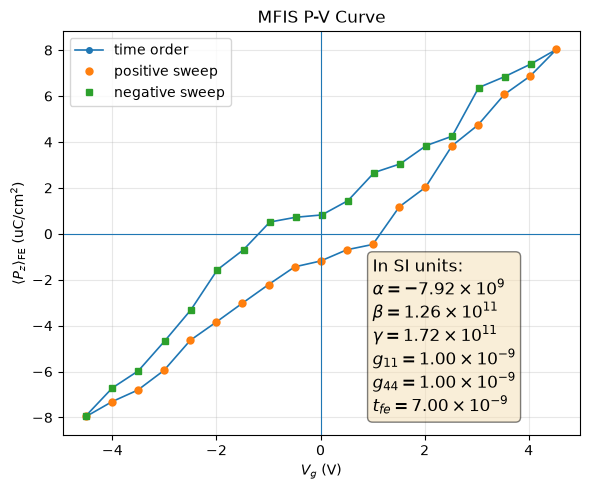

In [20]:
def sci_tex(x, sig=2):
    """Return LaTeX like 1.23\\times10^{-4} (no 'e')."""
    if x == 0:
        return r"0"
    exp = int(np.floor(np.log10(abs(x))))
    mant = x / (10 ** exp)
    return rf"{mant:.{sig}f}\times 10^{{{exp}}}"

# ==========================
# Plot PV curve
# ==========================

plt.figure(figsize=(6, 5))

textstr = '\n'.join((
    r'In SI units:',
    rf'$\alpha={sci_tex(ALPHA, sig=2)}$',
    rf'$\beta={sci_tex(BETA, sig=2)}$',
    rf'$\gamma={sci_tex(SMALL_GAMMA, sig=2)}$',
    rf'$g_{{11}}={sci_tex(G11, sig=2)}$',
    rf'$g_{{44}}={sci_tex(G44, sig=2)}$',
    rf'$t_{{fe}}={sci_tex((FE_Z_HI_NM-FE_Z_LO_NM)*1e-9, sig=2)}$',
))

props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
plt.text(1, -1, textstr, fontsize=12,
        verticalalignment='top', bbox=props)

# time-order full loop
plt.plot(V, -P*100, "-o", markersize=4, linewidth=1.2, label="time order")
# paper data
#plt.plot(Vp, Pp, "-o", markersize=4, linewidth=1.2, label="paper")
# no f data
#plt.plot(Vnf, -Pnf*100, "-o", markersize=4, linewidth=1.2, label="before")
# optional: highlight positive / negative sweep
pos = df["sweep_direction"].to_numpy() >= 0
neg = df["sweep_direction"].to_numpy() < 0

if np.any(pos):
    plt.plot(V[pos], -P[pos]*100, "o", markersize=5, label="positive sweep")

if np.any(neg):
    plt.plot(V[neg], -P[neg]*100, "s", markersize=5, label="negative sweep")


plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)

plt.xlabel(r"$V_g$ (V)")
plt.ylabel(r"$\langle P_z \rangle_\mathrm{FE}$ (uC/cm$^2$)")
plt.title("MFIS P-V Curve")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(OUT_FIG, dpi=200)
print(f"Saved figure: {OUT_FIG}")

plt.show()

# update html

## utils

In [21]:
from pathlib import Path
from datetime import datetime
import re


def make_image_cell(img_path):
    if img_path is None or img_path == "":
        return "<td>No Image</td>"

    return f"""
<td>
<a href="{img_path}" target="_blank">
<img src="{img_path}">
</a>
</td>
"""


def update_dashboard(
    folder,
    params,
    tfe,
    start_time=None,
    end_time=None,
    elapsed_time=None,
    pv=None,
    pz=None,
    html_file="index.html",
):
    """
    folder : 資料夾名稱 (例如 MFIS001)

    params : dict
        {
            "alpha":...,
            "beta":...,
            ...
        }

    tfe : float

    pv,pz : 相對於 index.html 的圖片路徑
    """

    html_file = Path(html_file)

    with open(html_file, encoding="utf8") as f:
        html = f.read()

    # ---------- 防止重複 ----------
    
    folders = set(
        re.findall(
            r'<tr>\s*<td[^>]*>(.*?)</td>',
            html,
            re.DOTALL
        )
    )

    if folder in folders:
        print(f"{folder} already exists. Skip.")
        return

    # ---------- 更新時間 ----------
    now = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

    html = re.sub(
        r'(<span id="last_update">).*?(</span>)',
        rf"\g<1>{now}\g<2>",
        html,
        flags=re.S,
    )

    # ---------- 更新總數 ----------
    # 網頁java自動更新總數，這裡不需要

    
    # ---------- 新增一列 ----------
    row = f'<tr>\n<td>{folder}</td>'

    wanted = [
        "alpha",
        "beta",
        "gamma",
        "BigGamma",
        "g11",
        "g44",
        "FE_lo",
        "FE_hi",
    ]

    for p in wanted:
        if p == "FE_lo" or p == "FE_hi":
            continue
            
        value = params.get(p)

        if value is None:
            txt = ""

        elif isinstance(value, list):
            txt = " ".join(f"{v:.3e}" for v in value)

        else:
            txt = f"{value:.3e}"

        row += f'<td>{txt}</td>'

    row += f'<td>{tfe:.3e}</td>'
    row += f'<td>{start_time}</td>'
    row += f'<td>{end_time}</td>'
    row += f'<td>{elapsed_time}</td>'
    
    

    row += make_image_cell(pv)

    row += make_image_cell(pz)

    row += "\n</tr>\n"
    
    html = html.replace(
        "</tbody>",
        row + "</tbody>",
    )

    with open(html_file, "w", encoding="utf8") as f:
        f.write(html)

    print(f"{folder} added.")

## main

In [22]:
from pathlib import Path

folder = Path.cwd().name
cwd = Path.cwd()

root = cwd.parent

pv = (cwd / "figs" / "MFIS_PV_curve.png").relative_to(root).as_posix()

pz = (cwd / "figs" / "Pz_FE_layer_stack.png").relative_to(root).as_posix()

update_dashboard(
    folder=folder,
    params=params,
    tfe=T_FE,
    start_time=start_time,
    end_time=end_time,
    elapsed_time=elapsed_hms,
    pv=pv,
    pz=pz,
    html_file=root / "index.html",
)




MFIS_t_7_nomi_18_var_7 added.


# update excel

## user settings

In [23]:
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
from openpyxl import Workbook, load_workbook


P_FIELD = ("boxlib", "Pz")
PHI_FIELD = ("boxlib", "Phi")

# 與原本畫圖程式相同：Pz 乘上 -1
P_SIGN = -1.0

USE_FE_X_RANGE = False
Y_INDEX = None

SKIP_INITIAL = True
SKIP_FIRST_N = 9

EXPERIMENT_COLUMNS = [
    "run_id",
    "folder",
    "inputs_path",
    "pv_csv_path",
    "pz_npz_path",
    "n_pv_points",
    "n_pz_stacks",
    "T_FE",
    "T_FE_nm",
    "Start Time",
    "End Time",
    "Elapsed",
    "Elapsed_sec",
    "alpha",
    "beta",
    "gamma",
    "BigGamma",
    "g11",
    "g44",
    "FE_lo",
    "FE_hi",
]

PV_COLUMNS = [
    "folder",
    "point_id",
    "V_applied",
    "branch",
    "P_mean",
]

PZ_INDEX_COLUMNS = [
    "folder",
    "point_id",
    "branch",
    "V_applied",
    "P_mean",
    "phi_available",
    "y_index",
    "y_nm",
    "full_shape",
    "slice_shape_Nx_Nz",
    "npz_path",
    "pz_array_key",
    "phi_array_key",
    "x_nm_key",
    "z_nm_key",
]

In [24]:
# 若前面的 notebook 已經定義 PLOT_DIR，就使用 PLOT_DIR
if "PLOT_DIR" in globals():
    CASE_DIR = Path(PLOT_DIR).resolve()
else:
    CASE_DIR = Path.cwd().resolve()

# PLOT_DIR 若是 case/plts，case folder 應該是上一層
if CASE_DIR.name == "plts":
    CASE_DIR = CASE_DIR.parent

PLOT_DIR_USE = CASE_DIR / "plts"

if not PLOT_DIR_USE.exists():
    PLOT_DIR_USE = CASE_DIR

FOLDER_NAME = CASE_DIR.name
ROOT_DIR = CASE_DIR.parent

# 共用 Excel
EXCEL_PATH = ROOT_DIR / "MFIS_dataset.xlsx"

# Pz/Phi npz 輸出位置
NPZ_DIR = ROOT_DIR / "extracted_pz" / FOLDER_NAME
NPZ_DIR.mkdir(parents=True, exist_ok=True)

NPZ_PATH = NPZ_DIR / "Pz_Phi_FE_all_voltage.npz"

print("CASE_DIR  :", CASE_DIR)
print("PLOT_DIR  :", PLOT_DIR_USE)
print("EXCEL_PATH:", EXCEL_PATH)
print("NPZ_PATH  :", NPZ_PATH)

CASE_DIR  : /home/bowei/FAM/FerroX/Exec/MFIS_t_7_nomi_18_var_7
PLOT_DIR  : /home/bowei/FAM/FerroX/Exec/MFIS_t_7_nomi_18_var_7/plts
EXCEL_PATH: /home/bowei/FAM/FerroX/Exec/MFIS_dataset.xlsx
NPZ_PATH  : /home/bowei/FAM/FerroX/Exec/extracted_pz/MFIS_t_7_nomi_18_var_7/Pz_Phi_FE_all_voltage.npz


## utils

In [25]:

def parse_date_line(line: str) -> datetime | None:
    """Parse date output like 'Fri Jun 19 00:36:36 CST 2026'.

    Python's %Z parsing for CST is system-dependent, so remove the timezone token.
    """
    line = line.strip()
    m = re.match(
        r"^(?P<dow>\w{3})\s+(?P<mon>\w{3})\s+(?P<day>\d{1,2})\s+"
        r"(?P<hms>\d{2}:\d{2}:\d{2})\s+(?P<tz>\S+)\s+(?P<year>\d{4})$",
        line,
    )
    if not m:
        return None
    s = f"{m.group('dow')} {m.group('mon')} {m.group('day')} {m.group('hms')} {m.group('year')}"
    try:
        return datetime.strptime(s, "%a %b %d %H:%M:%S %Y")
    except Exception:
        return None


def get_component_local(value, index):
    """取得 FE_lo / FE_hi 的指定 component。"""
    if value is None:
        return None

    if isinstance(value, (list, tuple, np.ndarray)):
        if len(value) <= index:
            return None

        try:
            return float(value[index])
        except (TypeError, ValueError):
            return None

    return None

def build_default_sweep(vmin=VOLTAGES[0], vmax=VOLTAGES[-1], dv=VOLTAGES[1] - VOLTAGES[0]):
    # Example: -4.5, -4.0, ..., 4.5, 4.0, ..., -4.5 => 37 points
    up = np.arange(vmin, vmax + 0.5 * dv, dv)
    down = np.arange(vmax - dv, vmin - 0.5 * dv, -dv)
    values = np.round(np.concatenate([up, down]), 12)
    branches = ["positive_sweep"] * len(up) + ["negative_sweep"] * len(down)
    return values, branches


def find_column_local(df, candidates):
    """忽略大小寫尋找 CSV 欄位。"""
    column_map = {
        str(column).strip().lower(): column
        for column in df.columns
    }

    for candidate in candidates:
        key = candidate.strip().lower()

        if key in column_map:
            return column_map[key]

    return None


def infer_branch_from_voltage(voltage):
    """根據相鄰 voltage 判斷 sweep direction。"""
    voltage = np.asarray(voltage, dtype=float)
    branch = []

    for i, value in enumerate(voltage):
        if (
            i == 0
            or not np.isfinite(value)
            or not np.isfinite(voltage[i - 1])
        ):
            branch.append("start")
            continue

        dv = value - voltage[i - 1]

        if dv > 1e-8:
            branch.append("positive sweep")
        elif dv < -1e-8:
            branch.append("negative sweep")
        else:
            branch.append("same V")

    return branch


def excel_value(value):
    """
    將 numpy/pandas 型別轉成 openpyxl 可以直接寫入的 Python 型別。
    NaN 轉成空白。
    """
    if value is None:
        return None

    if isinstance(value, np.generic):
        value = value.item()

    try:
        if pd.isna(value):
            return None
    except (TypeError, ValueError):
        pass

    if isinstance(value, (list, tuple, np.ndarray)):
        return " ".join(str(x) for x in value)

    return value

def read_inputs(path: Path) -> dict:
    params = {}
    with open(path, errors="ignore") as f:
        for line in f:
            line = line.strip()
            if not line or "=" not in line:
                continue
            key, value = line.split("=", 1)
            key = key.strip()
            if key not in wanted:
                continue
            try:
                params[key] = parse_value(value)
            except Exception:
                params[key] = value.split("#", 1)[0].strip()
    return params

# ============================================================
# Duplicate check
# ============================================================

def folder_exists_in_excel(
    excel_path: Path,
    folder_name: str,
) -> bool:
    """
    只看 experiments sheet 的 folder 欄位。

    已存在：
        return True

    Excel / sheet / folder 欄位不存在：
        return False
    """
    if not excel_path.exists():
        return False

    workbook = load_workbook(
        excel_path,
        read_only=True,
        data_only=True,
    )

    try:
        if "experiments" not in workbook.sheetnames:
            return False

        worksheet = workbook["experiments"]

        headers = [
            cell.value
            for cell in worksheet[1]
        ]

        if "folder" not in headers:
            return False

        folder_col = headers.index("folder") + 1

        for row_index in range(2, worksheet.max_row + 1):
            value = worksheet.cell(
                row=row_index,
                column=folder_col,
            ).value

            if str(value).strip() == folder_name:
                return True

        return False

    finally:
        workbook.close()


# ============================================================
# Read PV CSV
# ============================================================

def read_current_pv_curve(
    case_dir: Path,
    folder_name: str,
):
    csv_path = case_dir / "figs/MFIS_PV_curve.csv"

    if not csv_path.exists():
        raise FileNotFoundError(
            f"MFIS_PV_curve.csv not found: {csv_path}"
        )

    raw = pd.read_csv(csv_path)

    p_col = find_column_local(
        raw,
        ["P_mean", "Pavg", "P_average", "P"],
    )

    vapplied_col = find_column_local(
        raw,
        [
            "V_applied",
            "Vapp",
            "V_app",
            "gate_voltage",
            "Vg_applied",
        ],
    )

    if p_col is None:
        raise ValueError(
            "Cannot identify P_mean column. "
            f"CSV columns = {list(raw.columns)}"
        )

    n = len(raw)

    out = pd.DataFrame(
        index=np.arange(n)
    )

    out["folder"] = folder_name
    out["point_id"] = np.arange(
        n,
        dtype=int,
    )

    if vapplied_col is not None:
        # 優先使用 CSV 中實際存在的 applied voltage
        out["V_applied"] = pd.to_numeric(
            raw[vapplied_col],
            errors="coerce",
        )

        out["branch"] = infer_branch_from_voltage(
            out["V_applied"].to_numpy()
        )

    else:
        # CSV 沒有 V_applied 時，使用預設 sweep
        print(f"{folder_name}: CSV does not contain V_applied column. Using default sweep values.")
        sweep_values, sweep_branches = build_default_sweep()

        if n != len(sweep_values):
            raise ValueError(
                f"{folder_name}: CSV rows ({n}) do not match "
                f"default sweep points ({len(sweep_values)}).\n"
                f"Default sweep = "
                f"{sweep_values[0]} -> {np.max(sweep_values)} "
                f"-> {sweep_values[-1]}"
            )

        out["V_applied"] = sweep_values
        out["branch"] = sweep_branches

    out["P_mean"] = pd.to_numeric(
        raw[p_col],
        errors="coerce",
    )

    out = out.reindex(
        columns=PV_COLUMNS
    )

    return out


# ============================================================
# Read one Pz/Phi slice
# ============================================================

def read_one_plot(
    plotfile: Path,
    params: dict,
    yt_module,
    y_index=None,
):
    ds = yt_module.load(str(plotfile))

    if P_FIELD not in ds.field_list:
        raise RuntimeError(
            f"{plotfile}: field {P_FIELD} not found"
        )

    if PHI_FIELD not in ds.field_list:
        raise RuntimeError(
            f"{plotfile}: field {PHI_FIELD} not found"
        )

    P = read_full_field_from_grids(
        ds,
        P_FIELD,
    ).astype(np.float32)

    Phi = read_full_field_from_grids(
        ds,
        PHI_FIELD,
    ).astype(np.float32)

    P *= P_SIGN

    if P.shape != Phi.shape:
        raise RuntimeError(
            f"{plotfile}: Pz shape {P.shape} "
            f"!= Phi shape {Phi.shape}"
        )

    Nx, Ny, Nz = P.shape

    lo = np.asarray(
        ds.domain_left_edge.to_value(),
        dtype=float,
    )

    hi = np.asarray(
        ds.domain_right_edge.to_value(),
        dtype=float,
    )

    dx = (
        (hi - lo)
        / np.array([Nx, Ny, Nz], dtype=float)
    )

    x_nm = (
        lo[0]
        + (np.arange(Nx) + 0.5) * dx[0]
    ) * 1e9

    y_nm = (
        lo[1]
        + (np.arange(Ny) + 0.5) * dx[1]
    ) * 1e9

    z_nm = (
        lo[2]
        + (np.arange(Nz) + 0.5) * dx[2]
    ) * 1e9

    if y_index is None:
        y_index_use = Ny // 2
    else:
        y_index_use = int(y_index)

    if not 0 <= y_index_use < Ny:
        raise IndexError(
            f"y_index={y_index_use}, "
            f"but valid range is 0 to {Ny - 1}"
        )

    fe_lo = params.get("FE_lo")
    fe_hi = params.get("FE_hi")

    fe_z_lo = get_component_local(fe_lo, 2)
    fe_z_hi = get_component_local(fe_hi, 2)

    fe_x_lo = get_component_local(fe_lo, 0)
    fe_x_hi = get_component_local(fe_hi, 0)

    # FE z range
    if fe_z_lo is not None and fe_z_hi is not None:
        z_lo_nm = min(fe_z_lo, fe_z_hi) * 1e9
        z_hi_nm = max(fe_z_lo, fe_z_hi) * 1e9

        z_sel = (
            (z_nm >= z_lo_nm)
            & (z_nm <= z_hi_nm)
        )
    else:
        z_sel = np.ones_like(
            z_nm,
            dtype=bool,
        )

    # FE x range，預設不限制
    if (
        USE_FE_X_RANGE
        and fe_x_lo is not None
        and fe_x_hi is not None
    ):
        x_lo_nm = min(fe_x_lo, fe_x_hi) * 1e9
        x_hi_nm = max(fe_x_lo, fe_x_hi) * 1e9

        x_sel = (
            (x_nm >= x_lo_nm)
            & (x_nm <= x_hi_nm)
        )
    else:
        x_sel = np.ones_like(
            x_nm,
            dtype=bool,
        )

    if not np.any(x_sel):
        raise RuntimeError(
            f"{plotfile}: no cells selected in x direction"
        )

    if not np.any(z_sel):
        raise RuntimeError(
            f"{plotfile}: no cells selected in FE z direction"
        )

    # Pz、Phi 使用完全相同的 x/y/z selection
    P_slice = P[
        np.ix_(
            x_sel,
            [y_index_use],
            z_sel,
        )
    ][:, 0, :]

    Phi_slice = Phi[
        np.ix_(
            x_sel,
            [y_index_use],
            z_sel,
        )
    ][:, 0, :]

    return {
        "P_slice": P_slice,
        "Phi_slice": Phi_slice,

        "x_nm": x_nm[x_sel],
        "z_nm": z_nm[z_sel],

        "y_index": y_index_use,
        "y_nm": float(y_nm[y_index_use]),

        "full_shape": tuple(
            int(value)
            for value in P.shape
        ),

        "slice_shape": tuple(
            int(value)
            for value in P_slice.shape
        ),
    }


# ============================================================
# Extract all Pz/Phi stacks
# ============================================================

def extract_current_pz_phi(
    case_dir: Path,
    params: dict,
    pv_df: pd.DataFrame,
    output_npz: Path,
):
    try:
        import yt
    except ImportError as exc:
        raise RuntimeError(
            "yt is required for Pz/Phi extraction"
        ) from exc

    plot_dir = case_dir / "plts"

    if not plot_dir.exists():
        plot_dir = case_dir

    plot_names = find_plot_names(plot_dir)

    if SKIP_INITIAL:
        plot_names = [
            name
            for name in plot_names
            if get_step_from_name(name) != 0
        ]

    if SKIP_FIRST_N > 0:
        plot_names = plot_names[SKIP_FIRST_N:]

    if not plot_names:
        raise RuntimeError(
            "No plotfiles remain after filtering"
        )

    # 這裡刻意嚴格檢查，避免 PV 與 Pz/Phi 錯位後拿去訓練
    if len(plot_names) != len(pv_df):
        raise ValueError(
            f"PV rows ({len(pv_df)}) != "
            f"selected plotfiles ({len(plot_names)}).\n"
            "Do not save because the voltage-to-field mapping "
            "cannot be guaranteed."
        )

    pz_slices = []
    phi_slices = []
    plot_steps = []
    index_rows = []

    x_nm_ref = None
    z_nm_ref = None
    slice_shape_ref = None
    full_shape_ref = None
    y_index_ref = None
    y_nm_ref = None

    for stack_index, plot_name in enumerate(plot_names):
        plotfile = plot_dir / plot_name

        info = read_one_plot(
            plotfile=plotfile,
            params=params,
            yt_module=yt,
            y_index=Y_INDEX,
        )

        P_slice = np.asarray(
            info["P_slice"],
            dtype=np.float32,
        )

        Phi_slice_raw = info["Phi_slice"]
        phi_available = Phi_slice_raw is not None

        if phi_available:
            Phi_slice = np.asarray(
                Phi_slice_raw,
                dtype=np.float32,
            )
        else:
            Phi_slice = np.full(
                P_slice.shape,
                np.nan,
                dtype=np.float32,
            )

        if P_slice.shape != Phi_slice.shape:
            raise RuntimeError(
                f"{plotfile}: Pz slice shape {P_slice.shape} "
                f"!= Phi slice shape {Phi_slice.shape}"
            )

        if x_nm_ref is None:
            x_nm_ref = np.asarray(
                info["x_nm"],
                dtype=np.float64,
            )

            z_nm_ref = np.asarray(
                info["z_nm"],
                dtype=np.float64,
            )

            slice_shape_ref = P_slice.shape
            full_shape_ref = info["full_shape"]
            y_index_ref = int(info["y_index"])
            y_nm_ref = float(info["y_nm"])

        else:
            if P_slice.shape != slice_shape_ref:
                raise RuntimeError(
                    f"{plotfile}: slice shape changed from "
                    f"{slice_shape_ref} to {P_slice.shape}"
                )

            if not np.allclose(
                info["x_nm"],
                x_nm_ref,
            ):
                raise RuntimeError(
                    f"{plotfile}: x coordinates changed"
                )

            if not np.allclose(
                info["z_nm"],
                z_nm_ref,
            ):
                raise RuntimeError(
                    f"{plotfile}: z coordinates changed"
                )

        pz_slices.append(P_slice)
        phi_slices.append(Phi_slice)

        plot_step = get_step_from_name(
            plot_name
        )
        plot_steps.append(plot_step)

        pv_row = pv_df.iloc[stack_index]

        index_rows.append({
            "folder": case_dir.name,

            "point_id": int(
                pv_row.get("point_id", stack_index)
            ),

            "branch": pv_row.get(
                "branch",
                "unknown",
            ),

            "V_applied": pv_row.get(
                "V_applied",
                np.nan,
            ),

            "P_mean": pv_row.get(
                "P_mean",
                np.nan,
            ),

            "phi_available": phi_available,

            "y_index": int(
                info["y_index"]
            ),

            "y_nm": float(
                info["y_nm"]
            ),

            "full_shape": str(
                info["full_shape"]
            ),

            "slice_shape_Nx_Nz": str(
                info["slice_shape"]
            ),

            "npz_path": str(
                output_npz
            ),

            "pz_array_key": "Pz_stack",
            "phi_array_key": "Phi_stack",
            "x_nm_key": "x_nm",
            "z_nm_key": "z_nm",
        })

    Pz_stack = np.stack(
        pz_slices,
        axis=0,
    ).astype(np.float32)

    Phi_stack = np.stack(
        phi_slices,
        axis=0,
    ).astype(np.float32)

    np.savez_compressed(
        output_npz,

        # shape = (N_voltage, Nx, Nz)
        Pz_stack=Pz_stack,
        Phi_stack=Phi_stack,

        x_nm=x_nm_ref,
        z_nm=z_nm_ref,

        V_applied=pv_df[
            "V_applied"
        ].to_numpy(dtype=np.float64),

        
        P_mean=pv_df[
            "P_mean"
        ].to_numpy(dtype=np.float64),

        branch=pv_df[
            "branch"
        ].astype(str).to_numpy(),

        plot_step=np.asarray(
            [
                step if step is not None else -1
                for step in plot_steps
            ],
            dtype=np.int64,
        ),

        y_index=np.asarray(
            index_rows[0]["y_index"],
            dtype=np.int64,
        ),

        y_nm=np.asarray(
            index_rows[0]["y_nm"],
            dtype=np.float64,
        ),
    )

    print("Saved NPZ:", output_npz)
    print("Pz_stack shape :", Pz_stack.shape)
    print("Phi_stack shape:", Phi_stack.shape)
    
    pz_index_df = pd.DataFrame(index_rows)

    pz_index_df = pz_index_df.reindex(
        columns=PZ_INDEX_COLUMNS
    )

    return pz_index_df
    


# ============================================================
# Directly append DataFrame to an Excel sheet
# ============================================================

def get_last_nonempty_row(worksheet):
    """
    找出 worksheet 最後一個真正包含資料的 row。
    不依賴 worksheet.max_row，因為 max_row 可能包含空白格式列。
    """
    for row_index in range(worksheet.max_row, 0, -1):
        row_has_value = any(
            worksheet.cell(
                row=row_index,
                column=column_index,
            ).value not in (None, "")
            for column_index in range(
                1,
                worksheet.max_column + 1,
            )
        )

        if row_has_value:
            return row_index

    return 0


def remove_trailing_blank_rows(worksheet):
    """
    刪除 worksheet 最後方沒有資料的空白列。
    """
    last_nonempty_row = get_last_nonempty_row(
        worksheet
    )

    if worksheet.max_row > last_nonempty_row:
        worksheet.delete_rows(
            last_nonempty_row + 1,
            worksheet.max_row - last_nonempty_row,
        )


def append_dataframe_to_worksheet(
    workbook,
    sheet_name: str,
    dataframe: pd.DataFrame,
    expected_columns: list[str],
):
    if dataframe is None or dataframe.empty:
        return

    dataframe = dataframe.copy()

    # 固定欄位與順序
    dataframe = dataframe.reindex(
        columns=expected_columns
    )

    # 將空字串視為缺失值，再刪除整列皆空白的 row
    dataframe = dataframe.replace(
        r"^\s*$",
        np.nan,
        regex=True,
    )

    dataframe = dataframe.dropna(
        how="all"
    ).reset_index(drop=True)

    if dataframe.empty:
        print(
            f"[SKIP] '{sheet_name}' contains no valid rows."
        )
        return

    if sheet_name not in workbook.sheetnames:
        worksheet = workbook.create_sheet(
            title=sheet_name
        )

        # 寫入 header
        for column_index, column_name in enumerate(
            expected_columns,
            start=1,
        ):
            worksheet.cell(
                row=1,
                column=column_index,
                value=column_name,
            )

    else:
        worksheet = workbook[sheet_name]

        # 清除 sheet 尾端的假空白列
        remove_trailing_blank_rows(
            worksheet
        )

        existing_headers = [
            worksheet.cell(
                row=1,
                column=column_index,
            ).value
            for column_index in range(
                1,
                worksheet.max_column + 1,
            )
        ]

        while (
            existing_headers
            and existing_headers[-1] is None
        ):
            existing_headers.pop()

        if existing_headers != expected_columns:
            raise ValueError(
                f"Sheet '{sheet_name}' header mismatch.\n"
                f"Expected: {expected_columns}\n"
                f"Existing: {existing_headers}"
            )

    # 逐列 append
    for _, row in dataframe.iterrows():
        values = [
            excel_value(
                row[column_name]
            )
            for column_name in expected_columns
        ]

        # 再次避免整列都是 None
        if all(
            value in (None, "")
            for value in values
        ):
            continue

        worksheet.append(values)
def read_run_log(folder: Path):
    logfile = folder / "run.log"
    if not logfile.exists():
        logfile = folder / "plts" / "run.log"
    if not logfile.exists():
        return None, None, None, None

    with open(logfile, errors="ignore") as f:
        lines = [line.strip() for line in f if line.strip()]

    # Keep behavior close to your original script
    lines_tail = lines[-200:]

    end_time = None
    start_time = None
    elapsed_hms = None
    elapsed_sec = None

    if lines_tail:
        end_time = parse_date_line(lines_tail[-1])

    for line in lines_tail:
        if line.startswith("Total run time"):
            m = re.search(r"([\d.]+)", line)
            if m:
                elapsed_sec = float(m.group(1))
            break

    if elapsed_sec is not None:
        if end_time is not None:
            start_time = end_time - timedelta(seconds=elapsed_sec)

        h = int(elapsed_sec // 3600)
        m = int((elapsed_sec % 3600) // 60)
        s = int(elapsed_sec % 60)
        elapsed_hms = f"{h:02d}:{m:02d}:{s:02d}"

    return start_time, end_time, elapsed_hms, elapsed_sec

# ============================================================
# Build one experiment row
# ============================================================

def format_parameter_vector(value):
    """
    將 FE_lo、FE_hi 等 list/array 轉成可寫入 Excel 的字串。
    """
    if value is None:
        return ""

    if isinstance(value, (list, tuple, np.ndarray)):
        values = []

        for item in value:
            try:
                values.append(f"{float(item):.8e}")
            except (TypeError, ValueError):
                values.append(str(item))

        return " ".join(values)

    return str(value)


def build_experiment_dataframe(
    case_dir: Path,
    params: dict,
    pv_df: pd.DataFrame,
    pz_df: pd.DataFrame,
    npz_path: Path,
):
    run_id = case_dir.name

    fe_lo = params.get("FE_lo")
    fe_hi = params.get("FE_hi")

    fe_lo_z = get_component_local(
        fe_lo,
        2,
    )

    fe_hi_z = get_component_local(
        fe_hi,
        2,
    )

    if fe_lo_z is not None and fe_hi_z is not None:
        t_fe = abs(fe_hi_z - fe_lo_z)
    else:
        t_fe = np.nan

    # 使用你原本已有的 read_run_log()
    if "read_run_log" in globals():
        (
            start_time,
            end_time,
            elapsed_hms,
            elapsed_sec,
        ) = read_run_log(case_dir)
    else:
        start_time = None
        end_time = None
        elapsed_hms = None
        elapsed_sec = np.nan

    experiment = {
        "run_id": run_id,
        "folder": case_dir.name,

        "inputs_path": str(
            case_dir / "inputs"
        ),

        "pv_csv_path": str(
            case_dir / "MFIS_PV_curve.csv"
        ),

        "pz_npz_path": str(npz_path),

        "n_pv_points": len(pv_df),
        "n_pz_stacks": len(pz_df),

        "T_FE": t_fe,

        "T_FE_nm": (
            t_fe * 1e9
            if np.isfinite(t_fe)
            else np.nan
        ),

        "Start Time": start_time,
        "End Time": end_time,
        "Elapsed": elapsed_hms,
        "Elapsed_sec": elapsed_sec,

        "alpha": params.get("alpha", np.nan),
        "beta": params.get("beta", np.nan),
        "gamma": params.get("gamma", np.nan),
        "BigGamma": params.get("BigGamma", np.nan),
        "g11": params.get("g11", np.nan),
        "g44": params.get("g44", np.nan),

        "FE_lo": format_parameter_vector(fe_lo),
        "FE_hi": format_parameter_vector(fe_hi),
    }

    exp_df = pd.DataFrame([experiment])

    # 強制 experiments 欄位名稱和順序
    exp_df = exp_df.reindex(
        columns=EXPERIMENT_COLUMNS
    )

    return exp_df

## main

In [26]:
# ============================================================
# Main append block
# ============================================================

# 先判斷是否已經寫過。
# 放在 yt extraction 前面，可避免同一 notebook 重跑時重新讀所有 plotfiles。
if folder_exists_in_excel(
    EXCEL_PATH,
    FOLDER_NAME,
):
    print(
        f"[SKIP] {FOLDER_NAME} already exists "
        "in the experiments sheet."
    )

else:
    # --------------------------------------------------------
    # 1. Read parameters
    # --------------------------------------------------------
    inputs_path = CASE_DIR / "inputs"

    if not inputs_path.exists():
        raise FileNotFoundError(
            f"inputs not found: {inputs_path}"
        )

    # 使用你原本程式裡的 read_inputs()
    if "read_inputs" not in globals():
        raise NameError(
            "read_inputs() is not defined. "
            "Please run the inputs parsing cell first."
        )

    params_current = read_inputs(
        inputs_path
    )

    # --------------------------------------------------------
    # 2. Read PV curve
    # --------------------------------------------------------
    pv_df_current = read_current_pv_curve(
        case_dir=CASE_DIR,
        folder_name=FOLDER_NAME,
    )

    # --------------------------------------------------------
    # 3. Extract and save Pz/Phi
    # --------------------------------------------------------
    pz_df_current = extract_current_pz_phi(
        case_dir=CASE_DIR,
        params=params_current,
        pv_df=pv_df_current,
        output_npz=NPZ_PATH,
    )

    # --------------------------------------------------------
    # 4. Build experiments row
    # --------------------------------------------------------
    exp_df_current = build_experiment_dataframe(
        case_dir=CASE_DIR,
        params=params_current,
        pv_df=pv_df_current,
        pz_df=pz_df_current,
        npz_path=NPZ_PATH,
    )

    # --------------------------------------------------------
    # 5. Load or create Excel workbook
    # --------------------------------------------------------
    if EXCEL_PATH.exists():
        workbook = load_workbook(
            EXCEL_PATH
        )
    else:
        workbook = Workbook()

        # 移除 openpyxl 自動建立的 Sheet
        default_sheet = workbook.active
        workbook.remove(default_sheet)

    # --------------------------------------------------------
    # 6. Append all sheets in memory
    # --------------------------------------------------------
    append_dataframe_to_worksheet(
    workbook=workbook,
    sheet_name="experiments",
    dataframe=exp_df_current,
    expected_columns=EXPERIMENT_COLUMNS,
    )

    append_dataframe_to_worksheet(
        workbook=workbook,
        sheet_name="pv_curve",
        dataframe=pv_df_current,
        expected_columns=PV_COLUMNS,
    )

    append_dataframe_to_worksheet(
        workbook=workbook,
        sheet_name="pz_stack_index",
        dataframe=pz_df_current,
        expected_columns=PZ_INDEX_COLUMNS,
    )

    # 最後只 save 一次，避免只寫完一個 sheet 就中斷
    workbook.save(
        EXCEL_PATH
    )
    workbook.close()

    print("=" * 60)
    print("Append completed")
    print("Folder     :", FOLDER_NAME)
    print("Excel      :", EXCEL_PATH)
    print("PV points  :", len(pv_df_current))
    print("Pz/Phi     :", len(pz_df_current))
    print("=" * 60)

yt : [INFO     ] 2026-07-21 17:30:27,101 Parameters: current_time              = 4.1756000000009136e-09


yt : [INFO     ] 2026-07-21 17:30:27,102 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-07-21 17:30:27,103 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-07-21 17:30:27,104 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


yt : [INFO     ] 2026-07-21 17:30:27,219 Parameters: current_time              = 4.39260000000098e-09


...

yt : [INFO     ] 2026-07-21 17:30:31,716 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-07-21 17:30:31,717 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-07-21 17:30:31,718 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Saved NPZ: /home/bowei/FAM/FerroX/Exec/extracted_pz/MFIS_t_7_nomi_18_var_7/Pz_Phi_FE_all_voltage.npz
Pz_stack shape : (37, 64, 14)
Phi_stack shape: (37, 64, 14)


Append completed
Folder     : MFIS_t_7_nomi_18_var_7
Excel      : /home/bowei/FAM/FerroX/Exec/MFIS_dataset.xlsx
PV points  : 37
Pz/Phi     : 37
